In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)
import gc
import os
import importlib
from importlib import reload
import cv2
from tqdm.auto import tqdm
from collections import defaultdict

import ast
import seaborn as sns
import numpy as np
import os
import sys
import torch
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from pathlib import Path
from PIL import Image
import hashlib
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

from sklearn.metrics import roc_auc_score


os.chdir('..') # 상위 경로 이동
print("현재 경로:", os.getcwd())
root_dir = '/home/DAHS1/gangmin/my_research/'
new_dir_path = "/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/2rd_preprocessed_data/"

현재 경로: /home/DAHS1/gangmin/my_research/clinical_multimodal_learning


In [2]:
sequential_df_med = pd.read_feather(new_dir_path + "processed/sequential_df_med.ftr")
sequential_df_output = pd.read_feather(root_dir + "processed/processed_1013/sequential_df_output.ftr")
# imputed_df_chart = pd.read_feather(root_dir + "processed/imputed_df_chart_1223.ftr")
imputed_df_chart = pd.read_feather(new_dir_path + "processed/imputed_df_chart_20260423.ftr")
sequential_df_proc = pd.read_feather(new_dir_path + "processed/sequential_df_proc.ftr")
sequential_df_fluid = pd.read_feather(new_dir_path + "processed/sequential_df_fluid.ftr")

imputed_cxr_df = pd.read_feather(new_dir_path + '/processed/imputed_cxr_df_20260428.ftr')
imputed_text_df = pd.read_feather(root_dir+'/processed/imputed_text_df.ftr')
sequential_df_reports = pd.read_feather(root_dir + "processed/sequential_df_reports.ftr")

In [3]:
imputed_df_chart['itemid'].nunique()

19

In [4]:
# 결측값 제로 패딩
sequential_df_output['urine_output'] = sequential_df_output['urine_output'].fillna(0)
sequential_df_med['input_amount'] = sequential_df_med['input_amount'].fillna(0)
sequential_df_fluid['input_amount'] = sequential_df_fluid['input_amount'].fillna(0)

In [5]:
imputed_cxr_df['Edema'].value_counts()

Edema
 0.0    35162
 1.0    12411
-1.0     4496
Name: count, dtype: int64

---

In [6]:
imputed_df_chart.columns

Index(['stay_id', 'itemid', 'hour_slot', 'slot_start', 'value'], dtype='object')

In [7]:
df_pivot_value = imputed_df_chart.pivot_table(
    index=['stay_id', 'hour_slot'],   
    columns='itemid',                
    values=['value']
).reset_index()

df_pivot_value.columns = [
    str(col[1]) if col[0] == 'value' else f'{col[0]}_{str(col[1])}'
    for col in df_pivot_value.columns.values
]

In [8]:
df_pivot_value

,stay_id_,hour_slot_,50963,220045,220179,220180,220210,220277,220546,220615,220645,223761,223835,225624,225668,227073,227429,227442,227445,227446,227456
0,30000646,0,-2.0,101.000000,109.000000,65.500000,30.500000,97.500000,8.433333,0.933333,137.666667,-2.000000,-2.0,11.666667,-2.0,12.0,-2.00,3.666667,-2.0,-2.0,-2.0
1,30000646,1,-2.0,97.000000,97.000000,58.000000,19.000000,94.000000,8.433333,0.933333,137.666667,-2.000000,-2.0,11.666667,-2.0,12.0,-2.00,3.666667,-2.0,-2.0,-2.0
2,30000646,2,-2.0,93.000000,98.000000,57.000000,18.000000,98.000000,8.433333,0.933333,137.666667,-2.000000,-2.0,11.666667,-2.0,12.0,-2.00,3.666667,-2.0,-2.0,-2.0
3,30000646,3,-2.0,87.000000,98.000000,66.000000,24.000000,98.000000,8.433333,0.933333,137.666667,37.111111,-2.0,11.666667,-2.0,12.0,-2.00,3.666667,-2.0,-2.0,-2.0
4,30000646,4,-2.0,90.454545,96.714286,61.428571,30.454545,94.363636,10.600000,1.000000,141.000000,39.111111,100.0,12.000000,-2.0,12.0,0.02,3.700000,1.0,-2.0,-2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1618766,39998622,211,-2.0,113.000000,114.000000,75.000000,38.000000,95.000000,12.400000,1.000000,140.000000,36.888889,-2.0,34.000000,-2.0,14.0,-2.00,4.200000,-2.0,-2.0,-2.0
1618767,39998622,212,-2.0,111.000000,120.000000,71.000000,23.000000,94.000000,12.400000,1.000000,139.000000,36.888889,-2.0,38.000000,-2.0,12.0,-2.00,3.900000,-2.0,-2.0,-2.0
1618768,39998622,213,-2.0,108.000000,127.000000,82.000000,35.000000,93.000000,12.400000,1.000000,139.000000,36.944444,-2.0,38.000000,-2.0,12.0,-2.00,3.900000,-2.0,-2.0,-2.0
1618769,39998622,214,-2.0,106.000000,120.000000,71.000000,35.000000,93.000000,12.400000,1.000000,139.000000,36.944444,-2.0,38.000000,-2.0,12.0,-2.00,3.900000,-2.0,-2.0,-2.0


In [9]:
df_pivot_value.isnull().sum()

stay_id_      0
hour_slot_    0
50963         0
220045        0
220179        0
220180        0
220210        0
220277        0
220546        0
220615        0
220645        0
223761        0
223835        0
225624        0
225668        0
227073        0
227429        0
227442        0
227445        0
227446        0
227456        0
dtype: int64

In [10]:
mask = df_pivot_value['223835'] != -2
df_pivot_value.loc[mask, '223835'] = (df_pivot_value.loc[mask, '223835'] / 100)

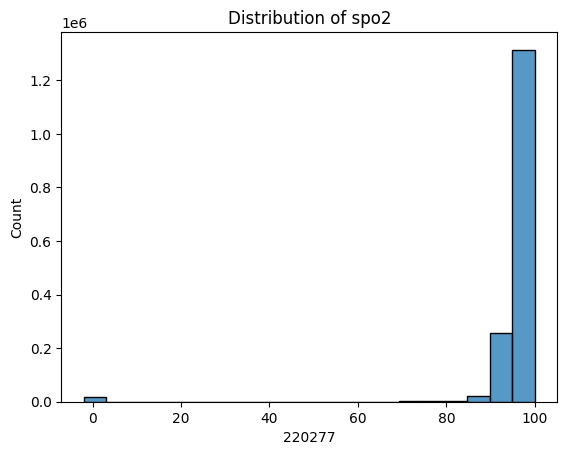

In [11]:
sns.histplot(df_pivot_value['220277'], bins=20)
plt.title('Distribution of spo2')
plt.show()

In [12]:
df_pivot_value

,stay_id_,hour_slot_,50963,220045,220179,220180,220210,220277,220546,220615,220645,223761,223835,225624,225668,227073,227429,227442,227445,227446,227456
0,30000646,0,-2.0,101.000000,109.000000,65.500000,30.500000,97.500000,8.433333,0.933333,137.666667,-2.000000,-2.0,11.666667,-2.0,12.0,-2.00,3.666667,-2.0,-2.0,-2.0
1,30000646,1,-2.0,97.000000,97.000000,58.000000,19.000000,94.000000,8.433333,0.933333,137.666667,-2.000000,-2.0,11.666667,-2.0,12.0,-2.00,3.666667,-2.0,-2.0,-2.0
2,30000646,2,-2.0,93.000000,98.000000,57.000000,18.000000,98.000000,8.433333,0.933333,137.666667,-2.000000,-2.0,11.666667,-2.0,12.0,-2.00,3.666667,-2.0,-2.0,-2.0
3,30000646,3,-2.0,87.000000,98.000000,66.000000,24.000000,98.000000,8.433333,0.933333,137.666667,37.111111,-2.0,11.666667,-2.0,12.0,-2.00,3.666667,-2.0,-2.0,-2.0
4,30000646,4,-2.0,90.454545,96.714286,61.428571,30.454545,94.363636,10.600000,1.000000,141.000000,39.111111,1.0,12.000000,-2.0,12.0,0.02,3.700000,1.0,-2.0,-2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1618766,39998622,211,-2.0,113.000000,114.000000,75.000000,38.000000,95.000000,12.400000,1.000000,140.000000,36.888889,-2.0,34.000000,-2.0,14.0,-2.00,4.200000,-2.0,-2.0,-2.0
1618767,39998622,212,-2.0,111.000000,120.000000,71.000000,23.000000,94.000000,12.400000,1.000000,139.000000,36.888889,-2.0,38.000000,-2.0,12.0,-2.00,3.900000,-2.0,-2.0,-2.0
1618768,39998622,213,-2.0,108.000000,127.000000,82.000000,35.000000,93.000000,12.400000,1.000000,139.000000,36.944444,-2.0,38.000000,-2.0,12.0,-2.00,3.900000,-2.0,-2.0,-2.0
1618769,39998622,214,-2.0,106.000000,120.000000,71.000000,35.000000,93.000000,12.400000,1.000000,139.000000,36.944444,-2.0,38.000000,-2.0,12.0,-2.00,3.900000,-2.0,-2.0,-2.0


In [13]:
def calculate_spo2_fio2(spo2, fio2):
    # -2가 있으면 NaN
    if spo2 == -2 or fio2 == -2:
        return np.nan
    # FiO2가 0이면 NaN (division by zero 방지)
    elif fio2 == 0.0:
        return np.nan
    else:
        return spo2 / fio2

df_pivot_value['spo2_fio2'] = df_pivot_value.apply(
    lambda row: calculate_spo2_fio2(row["220277"], row['223835']), 
    axis=1
)

In [14]:
df_pivot_value['220277']

0          97.500000
1          94.000000
2          98.000000
3          98.000000
4          94.363636
             ...    
1618766    95.000000
1618767    94.000000
1618768    93.000000
1618769    93.000000
1618770    93.000000
Name: 220277, Length: 1618771, dtype: float64

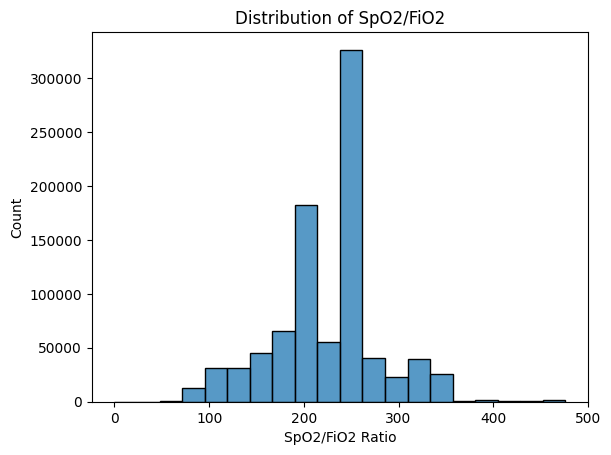

In [15]:
sns.histplot(df_pivot_value['spo2_fio2'], bins=20)
plt.title('Distribution of SpO2/FiO2')
plt.xlabel('SpO2/FiO2 Ratio')
plt.show()

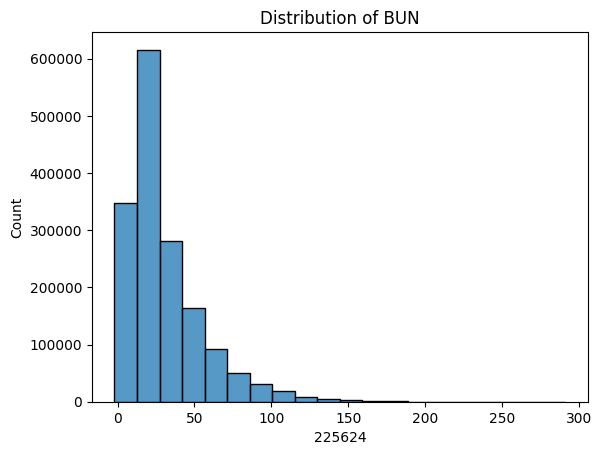

In [16]:
sns.histplot(df_pivot_value['225624'], bins=20)
plt.title('Distribution of BUN')
plt.show()

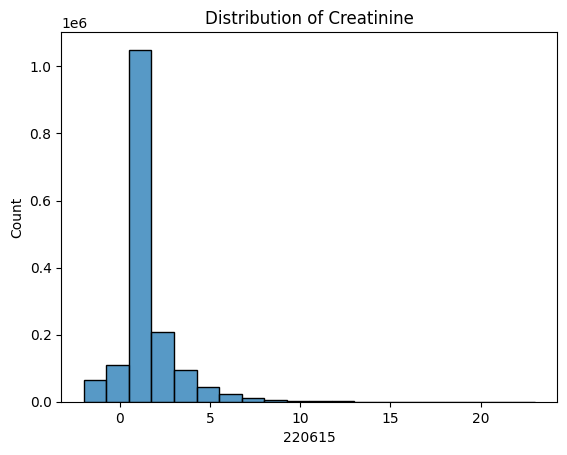

In [17]:
sns.histplot(df_pivot_value['220615'], bins=20)
plt.title('Distribution of Creatinine')
plt.show()

In [18]:
# BUN / Creatinine
def calculate_bun_creatinine(bun, creatinine):
    # -2가 있으면 NaN
    if bun == -2 or creatinine == -2:
        return np.nan
    # creatinine 0이면 NaN (division by zero 방지)
    elif creatinine == 0.0:
        return np.nan
    else:
        return bun / creatinine

df_pivot_value['bun_creatinine'] = df_pivot_value.apply(
    lambda row: calculate_bun_creatinine(row["225624"], row['220615']), 
    axis=1
)

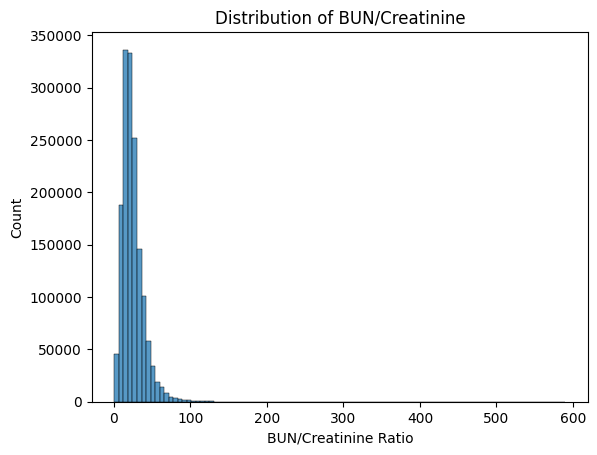

In [19]:
sns.histplot(df_pivot_value['bun_creatinine'], bins=100)
plt.title('Distribution of BUN/Creatinine')
plt.xlabel('BUN/Creatinine Ratio')
plt.show()

In [20]:
df_pivoted_chart = df_pivot_value.copy()
df_pivoted_chart

,stay_id_,hour_slot_,50963,220045,220179,220180,220210,220277,220546,220615,220645,223761,223835,225624,225668,227073,227429,227442,227445,227446,227456,spo2_fio2,bun_creatinine
0,30000646,0,-2.0,101.000000,109.000000,65.500000,30.500000,97.500000,8.433333,0.933333,137.666667,-2.000000,-2.0,11.666667,-2.0,12.0,-2.00,3.666667,-2.0,-2.0,-2.0,NaN,12.5
1,30000646,1,-2.0,97.000000,97.000000,58.000000,19.000000,94.000000,8.433333,0.933333,137.666667,-2.000000,-2.0,11.666667,-2.0,12.0,-2.00,3.666667,-2.0,-2.0,-2.0,NaN,12.5
2,30000646,2,-2.0,93.000000,98.000000,57.000000,18.000000,98.000000,8.433333,0.933333,137.666667,-2.000000,-2.0,11.666667,-2.0,12.0,-2.00,3.666667,-2.0,-2.0,-2.0,NaN,12.5
3,30000646,3,-2.0,87.000000,98.000000,66.000000,24.000000,98.000000,8.433333,0.933333,137.666667,37.111111,-2.0,11.666667,-2.0,12.0,-2.00,3.666667,-2.0,-2.0,-2.0,NaN,12.5
4,30000646,4,-2.0,90.454545,96.714286,61.428571,30.454545,94.363636,10.600000,1.000000,141.000000,39.111111,1.0,12.000000,-2.0,12.0,0.02,3.700000,1.0,-2.0,-2.0,94.363636,12.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1618766,39998622,211,-2.0,113.000000,114.000000,75.000000,38.000000,95.000000,12.400000,1.000000,140.000000,36.888889,-2.0,34.000000,-2.0,14.0,-2.00,4.200000,-2.0,-2.0,-2.0,NaN,34.0
1618767,39998622,212,-2.0,111.000000,120.000000,71.000000,23.000000,94.000000,12.400000,1.000000,139.000000,36.888889,-2.0,38.000000,-2.0,12.0,-2.00,3.900000,-2.0,-2.0,-2.0,NaN,38.0
1618768,39998622,213,-2.0,108.000000,127.000000,82.000000,35.000000,93.000000,12.400000,1.000000,139.000000,36.944444,-2.0,38.000000,-2.0,12.0,-2.00,3.900000,-2.0,-2.0,-2.0,NaN,38.0
1618769,39998622,214,-2.0,106.000000,120.000000,71.000000,35.000000,93.000000,12.400000,1.000000,139.000000,36.944444,-2.0,38.000000,-2.0,12.0,-2.00,3.900000,-2.0,-2.0,-2.0,NaN,38.0


In [21]:
# 같은 S/F라고 하더라도, FiO2 0.3에서 S/F 250과 FiO2 0.8에서 S/F 250의 치료 강도가 완전히 다르기 때문에, S/F+FiO2 조합을 사용하기로 해서, SpO2는 drop함.
df_pivoted_chart['spo2_fio2'] = (df_pivoted_chart['spo2_fio2'].fillna(-2))
df_pivoted_chart['bun_creatinine'] = (df_pivoted_chart['bun_creatinine'].fillna(-2))
df_pivoted_chart

,stay_id_,hour_slot_,50963,220045,220179,220180,220210,220277,220546,220615,220645,223761,223835,225624,225668,227073,227429,227442,227445,227446,227456,spo2_fio2,bun_creatinine
0,30000646,0,-2.0,101.000000,109.000000,65.500000,30.500000,97.500000,8.433333,0.933333,137.666667,-2.000000,-2.0,11.666667,-2.0,12.0,-2.00,3.666667,-2.0,-2.0,-2.0,-2.000000,12.5
1,30000646,1,-2.0,97.000000,97.000000,58.000000,19.000000,94.000000,8.433333,0.933333,137.666667,-2.000000,-2.0,11.666667,-2.0,12.0,-2.00,3.666667,-2.0,-2.0,-2.0,-2.000000,12.5
2,30000646,2,-2.0,93.000000,98.000000,57.000000,18.000000,98.000000,8.433333,0.933333,137.666667,-2.000000,-2.0,11.666667,-2.0,12.0,-2.00,3.666667,-2.0,-2.0,-2.0,-2.000000,12.5
3,30000646,3,-2.0,87.000000,98.000000,66.000000,24.000000,98.000000,8.433333,0.933333,137.666667,37.111111,-2.0,11.666667,-2.0,12.0,-2.00,3.666667,-2.0,-2.0,-2.0,-2.000000,12.5
4,30000646,4,-2.0,90.454545,96.714286,61.428571,30.454545,94.363636,10.600000,1.000000,141.000000,39.111111,1.0,12.000000,-2.0,12.0,0.02,3.700000,1.0,-2.0,-2.0,94.363636,12.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1618766,39998622,211,-2.0,113.000000,114.000000,75.000000,38.000000,95.000000,12.400000,1.000000,140.000000,36.888889,-2.0,34.000000,-2.0,14.0,-2.00,4.200000,-2.0,-2.0,-2.0,-2.000000,34.0
1618767,39998622,212,-2.0,111.000000,120.000000,71.000000,23.000000,94.000000,12.400000,1.000000,139.000000,36.888889,-2.0,38.000000,-2.0,12.0,-2.00,3.900000,-2.0,-2.0,-2.0,-2.000000,38.0
1618768,39998622,213,-2.0,108.000000,127.000000,82.000000,35.000000,93.000000,12.400000,1.000000,139.000000,36.944444,-2.0,38.000000,-2.0,12.0,-2.00,3.900000,-2.0,-2.0,-2.0,-2.000000,38.0
1618769,39998622,214,-2.0,106.000000,120.000000,71.000000,35.000000,93.000000,12.400000,1.000000,139.000000,36.944444,-2.0,38.000000,-2.0,12.0,-2.00,3.900000,-2.0,-2.0,-2.0,-2.000000,38.0


In [22]:
sequential_df_med.columns

Index(['hadm_id', 'stay_id', 'hour_slot', 'slot_start', 'slot_end', 'itemid',
       'input_amount'],
      dtype='object')

In [23]:
# input
df_pivot_input = sequential_df_med.pivot_table(
    index=['stay_id', 'hour_slot'],
    columns='itemid',                
    values=['input_amount']
).reset_index()

df_pivot_input.columns = [
    str(col[1]) if col[0] == 'input_amount' else f'{col[0]}_{str(col[1])}'
    for col in df_pivot_input.columns.values
]

df_pivot_input

,stay_id_,hour_slot_,221653,221662,221749,221794,221906,221986,222051,222056,225168,225974
0,30000646,0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
1,30000646,1,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
2,30000646,2,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
3,30000646,3,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
4,30000646,4,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1618766,39998622,211,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
1618767,39998622,212,0.0,0.0,0.0,40.000003,0.0,0.0,0.0,0.0,0.0,0.0
1618768,39998622,213,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
1618769,39998622,214,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0


In [24]:
print(sequential_df_proc['stay_id'].nunique())
print(sequential_df_proc['hadm_id'].nunique())

14146
12985


In [25]:
hadm_df = sequential_df_proc[['hadm_id', 'stay_id']].drop_duplicates().reset_index(drop=True)
hadm_df

,hadm_id,stay_id
0,26184834,37510196
1,23473524,35479615
2,28662225,33987268
3,28662225,38875437
4,20214994,32128372
...,...,...
14141,24096838,33428243
14142,24842066,30988867
14143,20175828,35165301
14144,26785317,32336619


In [26]:
# procedure
df_pivot_proc = sequential_df_proc.pivot_table(
    index=['stay_id', 'hour_slot'],
    columns='itemid',                
    values=['procedure_flag']
).reset_index()

df_pivot_proc.columns = [
    str(col[1]) if col[0] == 'procedure_flag' else f'{col[0]}_{str(col[1])}'
    for col in df_pivot_proc.columns.values
]

df_pivot_proc

,stay_id_,hour_slot_,225402,225794
0,30000646,0,1.0,0.0
1,30000646,1,0.0,0.0
2,30000646,2,0.0,0.0
3,30000646,3,0.0,0.0
4,30000646,4,1.0,0.0
...,...,...,...,...
1618766,39998622,211,0.0,0.0
1618767,39998622,212,0.0,0.0
1618768,39998622,213,0.0,0.0
1618769,39998622,214,0.0,0.0


In [27]:
sequential_df_output

,hadm_id,stay_id,hour_slot,slot_start,slot_end,urine_output
0,26184834,37510196,0,2131-01-11 04:20:05,2131-01-11 05:20:05,0.000000
1,26184834,37510196,1,2131-01-11 05:20:05,2131-01-11 06:20:05,0.000000
2,26184834,37510196,2,2131-01-11 06:20:05,2131-01-11 07:20:05,92.048611
3,26184834,37510196,3,2131-01-11 07:20:05,2131-01-11 08:20:05,215.296022
4,26184834,37510196,4,2131-01-11 08:20:05,2131-01-11 09:20:05,123.782818
...,...,...,...,...,...,...
1618766,23865745,36195440,42,2145-11-04 16:59:00,2145-11-04 17:59:00,0.000000
1618767,23865745,36195440,43,2145-11-04 17:59:00,2145-11-04 18:59:00,0.000000
1618768,23865745,36195440,44,2145-11-04 18:59:00,2145-11-04 19:59:00,303.333333
1618769,23865745,36195440,45,2145-11-04 19:59:00,2145-11-04 20:59:00,21.666667


In [28]:
sequential_df_output = sequential_df_output[['stay_id', 'hour_slot', 'urine_output']]
sequential_df_output = sequential_df_output.rename(columns={'urine_output': 'urine'})
sequential_df_output = sequential_df_output.sort_values(['stay_id', 'hour_slot']).reset_index(drop=True)

In [29]:
sequential_df_output

,stay_id,hour_slot,urine
0,30000646,0,0.000000
1,30000646,1,0.000000
2,30000646,2,0.000000
3,30000646,3,529.277778
4,30000646,4,170.722222
...,...,...,...
1618766,39998622,211,40.473164
1618767,39998622,212,292.896153
1618768,39998622,213,478.226729
1618769,39998622,214,175.741525


In [30]:
sequential_df_fluid

,hadm_id,stay_id,hour_slot,slot_start,slot_end,fluid_category,input_amount
0,26184834,37510196,0,2131-01-11 04:20:05,2131-01-11 05:20:05,fluid_alb,0.0
1,26184834,37510196,1,2131-01-11 05:20:05,2131-01-11 06:20:05,fluid_alb,0.0
2,26184834,37510196,2,2131-01-11 06:20:05,2131-01-11 07:20:05,fluid_alb,0.0
3,26184834,37510196,3,2131-01-11 07:20:05,2131-01-11 08:20:05,fluid_alb,0.0
4,26184834,37510196,4,2131-01-11 08:20:05,2131-01-11 09:20:05,fluid_alb,0.0
...,...,...,...,...,...,...,...
3237537,23865745,36195440,42,2145-11-04 16:59:00,2145-11-04 17:59:00,fluid_cyst,0.0
3237538,23865745,36195440,43,2145-11-04 17:59:00,2145-11-04 18:59:00,fluid_cyst,0.0
3237539,23865745,36195440,44,2145-11-04 18:59:00,2145-11-04 19:59:00,fluid_cyst,0.0
3237540,23865745,36195440,45,2145-11-04 19:59:00,2145-11-04 20:59:00,fluid_cyst,201.2


In [31]:
# fluid
df_pivot_fluid = sequential_df_fluid.pivot_table(
    index=['stay_id', 'hour_slot'],
    columns='fluid_category',                
    values=['input_amount']
).reset_index()

df_pivot_fluid.columns = [
    str(col[1]) if col[0] == 'input_amount' else f'{col[0]}_{str(col[1])}'
    for col in df_pivot_fluid.columns.values
]

df_pivot_fluid

,stay_id_,hour_slot_,fluid_alb,fluid_cyst
0,30000646,0,0.0,320.614289
1,30000646,1,0.0,5.000507
2,30000646,2,0.0,5.000507
3,30000646,3,0.0,5.000507
4,30000646,4,0.0,3365.000507
...,...,...,...,...
1618766,39998622,211,0.0,105.000000
1618767,39998622,212,0.0,5.000000
1618768,39998622,213,0.0,5.000000
1618769,39998622,214,0.0,5.000000


In [32]:
df_pivoted_chart = df_pivoted_chart.rename(columns={'stay_id_': 'stay_id', 'hour_slot_': 'hour_slot'})
df_pivot_input = df_pivot_input.rename(columns={'stay_id_': 'stay_id', 'hour_slot_': 'hour_slot'})
df_pivot_fluid = df_pivot_fluid.rename(columns={'stay_id_': 'stay_id', 'hour_slot_': 'hour_slot'})
df_pivot_proc = df_pivot_proc.rename(columns={'stay_id_': 'stay_id', 'hour_slot_': 'hour_slot'})

from functools import reduce

def merge_all_icu_events(df_chart, df_med, df_fluid, df_proc, df_output):    
    dataframes = [df_chart, df_med, df_fluid, df_proc, df_output]

    icu_events = reduce(lambda left, right: pd.merge(left, right, on=['stay_id', 'hour_slot'], how='left'), dataframes)

    icu_events.columns = icu_events.columns.map(str)

    return icu_events

icu_events_df = merge_all_icu_events(df_pivoted_chart, df_pivot_input, df_pivot_fluid, df_pivot_proc, sequential_df_output)

In [33]:
icu_events_df

,stay_id,hour_slot,50963,220045,220179,220180,220210,220277,220546,220615,220645,223761,223835,225624,225668,227073,227429,227442,227445,227446,227456,spo2_fio2,bun_creatinine,221653,221662,221749,221794,221906,221986,222051,222056,225168,225974,fluid_alb,fluid_cyst,225402,225794,urine
0,30000646,0,-2.0,101.000000,109.000000,65.500000,30.500000,97.500000,8.433333,0.933333,137.666667,-2.000000,-2.0,11.666667,-2.0,12.0,-2.00,3.666667,-2.0,-2.0,-2.0,-2.000000,12.5,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,320.614289,1.0,0.0,0.000000
1,30000646,1,-2.0,97.000000,97.000000,58.000000,19.000000,94.000000,8.433333,0.933333,137.666667,-2.000000,-2.0,11.666667,-2.0,12.0,-2.00,3.666667,-2.0,-2.0,-2.0,-2.000000,12.5,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.000507,0.0,0.0,0.000000
2,30000646,2,-2.0,93.000000,98.000000,57.000000,18.000000,98.000000,8.433333,0.933333,137.666667,-2.000000,-2.0,11.666667,-2.0,12.0,-2.00,3.666667,-2.0,-2.0,-2.0,-2.000000,12.5,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.000507,0.0,0.0,0.000000
3,30000646,3,-2.0,87.000000,98.000000,66.000000,24.000000,98.000000,8.433333,0.933333,137.666667,37.111111,-2.0,11.666667,-2.0,12.0,-2.00,3.666667,-2.0,-2.0,-2.0,-2.000000,12.5,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.000507,0.0,0.0,529.277778
4,30000646,4,-2.0,90.454545,96.714286,61.428571,30.454545,94.363636,10.600000,1.000000,141.000000,39.111111,1.0,12.000000,-2.0,12.0,0.02,3.700000,1.0,-2.0,-2.0,94.363636,12.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3365.000507,1.0,0.0,170.722222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1618766,39998622,211,-2.0,113.000000,114.000000,75.000000,38.000000,95.000000,12.400000,1.000000,140.000000,36.888889,-2.0,34.000000,-2.0,14.0,-2.00,4.200000,-2.0,-2.0,-2.0,-2.000000,34.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,105.000000,0.0,0.0,40.473164
1618767,39998622,212,-2.0,111.000000,120.000000,71.000000,23.000000,94.000000,12.400000,1.000000,139.000000,36.888889,-2.0,38.000000,-2.0,12.0,-2.00,3.900000,-2.0,-2.0,-2.0,-2.000000,38.0,0.0,0.0,0.0,40.000003,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.000000,0.0,0.0,292.896153
1618768,39998622,213,-2.0,108.000000,127.000000,82.000000,35.000000,93.000000,12.400000,1.000000,139.000000,36.944444,-2.0,38.000000,-2.0,12.0,-2.00,3.900000,-2.0,-2.0,-2.0,-2.000000,38.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.000000,0.0,0.0,478.226729
1618769,39998622,214,-2.0,106.000000,120.000000,71.000000,35.000000,93.000000,12.400000,1.000000,139.000000,36.944444,-2.0,38.000000,-2.0,12.0,-2.00,3.900000,-2.0,-2.0,-2.0,-2.000000,38.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.000000,0.0,0.0,175.741525


In [34]:
icu_events_df = hadm_df.merge(icu_events_df, how='left', on='stay_id')
icu_events_df = icu_events_df.sort_values(by=['hadm_id', 'stay_id', 'hour_slot']).reset_index(drop=True)
icu_events_df

,hadm_id,stay_id,hour_slot,50963,220045,220179,220180,220210,220277,220546,220615,220645,223761,223835,225624,225668,227073,227429,227442,227445,227446,227456,spo2_fio2,bun_creatinine,221653,221662,221749,221794,221906,221986,222051,222056,225168,225974,fluid_alb,fluid_cyst,225402,225794,urine
0,20001305,36916968,0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.000000,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.000000,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000
1,20001305,36916968,1,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,12.6,-2.0,-2.0,-2.000000,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.000000,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000
2,20001305,36916968,2,-2.0,76.0,89.0,36.0,18.0,100.0,12.6,-2.0,-2.0,36.833333,0.5,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,200.000000,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2002.891291,0.0,0.0,14.787500
3,20001305,36916968,3,-2.0,73.0,79.0,40.0,25.0,100.0,12.6,-2.0,-2.0,36.833333,0.5,-2.0,2.3,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,200.000000,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2004.206426,0.0,0.0,0.212500
4,20001305,36916968,4,-2.0,66.0,88.0,45.0,20.0,100.0,12.6,-2.0,-2.0,36.833333,0.5,-2.0,2.3,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,200.000000,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.111092,0.0,0.0,18.716667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1618766,29999098,33475199,261,-2.0,63.0,-2.0,-2.0,16.0,95.0,22.8,1.0,153.0,36.722222,0.6,20.0,1.3,16.0,-2.0,3.4,-2.0,-2.0,2.8,158.333333,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,82.203390
1618767,29999098,33475199,262,-2.0,69.0,-2.0,-2.0,16.0,97.0,22.8,1.0,153.0,36.444444,0.7,20.0,1.3,16.0,-2.0,3.4,-2.0,-2.0,2.8,138.571429,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,100.000000
1618768,29999098,33475199,263,-2.0,68.0,-2.0,-2.0,16.0,96.0,22.8,1.0,153.0,36.444444,0.7,20.0,1.3,16.0,-2.0,3.4,-2.0,-2.0,2.8,137.142857,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,114.406780
1618769,29999098,33475199,264,-2.0,69.0,-2.0,-2.0,16.0,94.0,22.8,1.0,153.0,36.444444,0.7,20.0,1.3,16.0,-2.0,3.4,-2.0,-2.0,2.8,134.285714,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,106.779661


In [35]:
icu_events_df.columns

Index(['hadm_id', 'stay_id', 'hour_slot', '50963', '220045', '220179',
       '220180', '220210', '220277', '220546', '220615', '220645', '223761',
       '223835', '225624', '225668', '227073', '227429', '227442', '227445',
       '227446', '227456', 'spo2_fio2', 'bun_creatinine', '221653', '221662',
       '221749', '221794', '221906', '221986', '222051', '222056', '225168',
       '225974', 'fluid_alb', 'fluid_cyst', '225402', '225794', 'urine'],
      dtype='object')

In [36]:
# icu_events_df.to_feather("/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/2rd_preprocessed_data/processed/icu_events_df.ftr")

In [37]:
imputed_cxr_df['Edema'].value_counts()

Edema
 0.0    35162
 1.0    12411
-1.0     4496
Name: count, dtype: int64

In [38]:
test = imputed_cxr_df[imputed_cxr_df['image_path'].notnull()]

In [39]:
test

,hadm_id,stay_id,hour_slot,slot_start,slot_end,cxr_flag,image_path,cxrtime,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardiomediastinum,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices,was_missing
0,26184834,37510196,0,2131-01-11 04:20:05,2131-01-11 05:20:05,1,files/p10/p10001884/s57156853/9fd47edd-0708720...,2131-01-10 12:54:30.328,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
24,26184834,37510196,24,2131-01-12 04:20:05,2131-01-12 05:20:05,1,files/p10/p10001884/s50712381/7b25b3ed-e780a52...,2131-01-12 04:56:56.359,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
48,26184834,37510196,48,2131-01-13 04:20:05,2131-01-13 05:20:05,1,files/p10/p10001884/s56722923/c1ad3e27-62d05ef...,2131-01-13 04:49:18.484,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
78,26184834,37510196,78,2131-01-14 10:20:05,2131-01-14 11:20:05,1,files/p10/p10001884/s59305618/9b1a8a51-2b8e4a0...,2131-01-14 10:34:28.765,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,1.0,0.0,-1.0,0.0,-1.0,0.0,1.0,1.0
96,26184834,37510196,96,2131-01-15 04:20:05,2131-01-15 05:20:05,1,files/p10/p10001884/s50376803/469d0d94-3dad506...,2131-01-15 04:45:09.078,0.0,1.0,-1.0,0.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1618525,20175828,35165301,81,2197-08-07 09:02:00,2197-08-07 10:02:00,1,files/p19/p19999287/s52519175/f7e95a22-cb95805...,2197-08-07 09:06:37.796,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
1618543,20175828,35165301,99,2197-08-08 03:02:00,2197-08-08 04:02:00,1,files/p19/p19999287/s50000173/c8bbb9ff-ecb81ef...,2197-08-08 03:15:49.890,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1618565,26785317,32336619,8,2148-11-19 22:23:43,2148-11-19 23:23:43,1,files/p19/p19999442/s58708861/16b6c70f-6d36bd7...,2148-11-19 22:47:03.375,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
1618730,23865745,36195440,6,2145-11-03 04:59:00,2145-11-03 05:59:00,1,files/p19/p19999987/s58971208/1a1fe7e3-cbac5d9...,2145-11-03 05:05:07.625,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [40]:
# CXR_LABEL_COLS = [
#     'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Enlarged Cardiomediastinum', 'Fracture', 'Lung Lesion', 'Lung Opacity', 
#     'No Finding', 'Pleural Effusion', 'Pleural Other', 'Pneumonia', 'Pneumothorax', 'Support Devices'
# ]

CXR_LABEL_COLS = [
    'Edema'
]

# chexpert U-Ones (Uncertain to Positive)
# imputed_cxr_df.loc[:, CXR_LABEL_COLS] = imputed_cxr_df[CXR_LABEL_COLS].fillna(0)
imputed_cxr_df.loc[:, CXR_LABEL_COLS] = imputed_cxr_df[CXR_LABEL_COLS].replace(-1, 1)

In [41]:
imputed_cxr_df

,hadm_id,stay_id,hour_slot,slot_start,slot_end,cxr_flag,image_path,cxrtime,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardiomediastinum,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices,was_missing
0,26184834,37510196,0,2131-01-11 04:20:05,2131-01-11 05:20:05,1,files/p10/p10001884/s57156853/9fd47edd-0708720...,2131-01-10 12:54:30.328,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
1,26184834,37510196,1,2131-01-11 05:20:05,2131-01-11 06:20:05,0,None,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2,26184834,37510196,2,2131-01-11 06:20:05,2131-01-11 07:20:05,0,None,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
3,26184834,37510196,3,2131-01-11 07:20:05,2131-01-11 08:20:05,0,None,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
4,26184834,37510196,4,2131-01-11 08:20:05,2131-01-11 09:20:05,0,None,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1618766,23865745,36195440,42,2145-11-04 16:59:00,2145-11-04 17:59:00,0,None,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
1618767,23865745,36195440,43,2145-11-04 17:59:00,2145-11-04 18:59:00,0,None,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
1618768,23865745,36195440,44,2145-11-04 18:59:00,2145-11-04 19:59:00,0,None,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
1618769,23865745,36195440,45,2145-11-04 19:59:00,2145-11-04 20:59:00,0,None,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0


In [42]:
# 리샘플링 데이터셋에 라벨 할당 
def static_cxr_edema_labeling(df, cols, identifier, limit_hours=24): # 과거 limit_hours=24
    processed_list = []

    for stay_id, group in df.groupby(identifier):
        group = group.copy()

        current_labels = {col: None for col in cols}
        label_start_hours = {col: None for col in cols}
        label_source = [None] * len(group)

        # cxr 라벨 기준 라벨 추출
        for i, (idx, row) in enumerate(group.iterrows()):
            row_source = None
            
            for col in cols:
                if row['cxr_flag']==1 and not pd.isna(row[col]):
                    current_labels[col] = row[col]
                    label_start_hours[col] = row['hour_slot']
                    group.at[idx, col] = current_labels[col]
                    row_source = 'original'

                elif current_labels[col] is not None:
                    hour_diff = row['hour_slot'] - label_start_hours[col]

                    if hour_diff <= limit_hours:
                        group.at[idx, col] = current_labels[col]
                        if row_source is None:
                            row_source = 'ffilled'
                    else: 
                        current_labels[col] = None
                        label_start_hours[col] = None

            label_source[i] = row_source
        
        group['label_source'] = label_source
        processed_list.append(group)

    df = pd.concat(processed_list).sort_index()
    return df

label_imputed_cxr = static_cxr_edema_labeling(imputed_cxr_df, cols=CXR_LABEL_COLS, identifier='stay_id', limit_hours=0)

In [43]:
# def asymmetric_soft_labeling(df, cols, identifier='stay_id', lambda_up=3.0, lambda_down=2.0, limit_hours=48):
#     """
#     비대칭 지수 감쇠(Asymmetric Exponential Decay)를 적용한 소프트 라벨링

#     - lambda_up: 0 -> 1 악화 구간의 하이퍼파라미터. (클수록 막판에 급격히 상승)
#     - lambda_down: 1 -> 0 호전 구간의 하이퍼파라미터. (클수록 초반에 급격히 감소)
#     """
#     df = df.copy()

#     for col in cols:
#         # 1. 관측값이 존재하는(CXR 촬영이 있는) 행의 마스크
#         obs_mask = (df['cxr_flag'] == 1) & (df[col].notna())

#         # 2. 임시 컬럼 생성 및 환자별 앞뒤 관측값 매핑 (벡터화 연산)
#         df['temp_label'] = np.where(obs_mask, df[col], np.nan)
#         df['temp_time'] = np.where(obs_mask, df['hour_slot'], np.nan)

#         df['prev_label'] = df.groupby(identifier)['temp_label'].ffill()
#         df['prev_time'] = df.groupby(identifier)['temp_time'].ffill()
        
#         df['next_label'] = df.groupby(identifier)['temp_label'].bfill()
#         df['next_time'] = df.groupby(identifier)['temp_time'].bfill()

#         # 3. 시간 간격 및 정규화된 진행 시간(x) 계산 (0 <= x <= 1)
#         delta_t_total = df['next_time'] - df['prev_time']
#         delta_t_current = df['hour_slot'] - df['prev_time']
        
#         # 분모가 0이 되는 것(관측 당일)을 방지
#         x = np.where(delta_t_total > 0, delta_t_current / delta_t_total, 0)

#         # 4. 구간별 소프트 라벨 적용
#         soft_label = pd.Series(np.nan, index=df.index)

#         # [당일] 원본 라벨 유지
#         soft_label.loc[obs_mask] = df.loc[obs_mask, col]

#         # [0 -> 0 구간] 0.0 유지
#         idx_00 = (~obs_mask) & (df['prev_label'] == 0) & (df['next_label'] == 0)
#         soft_label.loc[idx_00] = 0.0

#         # [1 -> 1 구간] 1.0 유지
#         idx_11 = (~obs_mask) & (df['prev_label'] == 1) & (df['next_label'] == 1)
#         soft_label.loc[idx_11] = 1.0

#         # [0 -> 1 구간] 급격한 상승 (악화)
#         idx_01 = (~obs_mask) & (df['prev_label'] == 0) & (df['next_label'] == 1)
#         if idx_01.sum() > 0:
#             val_x = x[idx_01]
#             soft_label.loc[idx_01] = (np.exp(lambda_up * val_x) - 1) / (np.exp(lambda_up) - 1)

#         # [1 -> 0 구간] 점진적 감쇠 (호전)
#         idx_10 = (~obs_mask) & (df['prev_label'] == 1) & (df['next_label'] == 0)
#         if idx_10.sum() > 0:
#             val_x = x[idx_10]
#             soft_label.loc[idx_10] = (np.exp(-lambda_down * val_x) - np.exp(-lambda_down)) / (1 - np.exp(-lambda_down))

#         # [마지막 관측 이후] limit_hours 까지만 감쇠 적용
#         idx_last = (~obs_mask) & df['prev_label'].notna() & df['next_label'].isna()
#         if idx_last.sum() > 0:
#             within_limit = delta_t_current <= limit_hours
#             idx_valid = idx_last & within_limit

#             # 1에서 끝난 경우: 일반적인 지수 감쇠
#             idx_last_1 = idx_valid & (df['prev_label'] == 1)
#             if idx_last_1.sum() > 0:
#                 decay_rate = lambda_down / 24.0 # 24시간 기준 스케일링
#                 soft_label.loc[idx_last_1] = np.exp(-decay_rate * delta_t_current[idx_last_1])

#             # 0에서 끝난 경우: 0 유지
#             idx_last_0 = idx_valid & (df['prev_label'] == 0)
#             soft_label.loc[idx_last_0] = 0.0

#         # 5. 기존 DataFrame 업데이트 및 소스 기록
#         df[col] = soft_label
#         df['label_source'] = np.where(obs_mask, 'original', np.where(soft_label.notna(), 'soft_imputed', np.nan))

#     # 임시 컬럼 정리
#     df = df.drop(columns=['temp_label', 'temp_time', 'prev_label', 'prev_time', 'next_label', 'next_time'])
    
#     return df

# # 함수 실행 (limit_hours는 데이터 특성에 맞게 재조정 가능)
# # label_imputed_cxr = asymmetric_soft_labeling(imputed_cxr_df, cols=CXR_LABEL_COLS, identifier='stay_id', limit_hours=48)

In [44]:
label_imputed_cxr

,hadm_id,stay_id,hour_slot,slot_start,slot_end,cxr_flag,image_path,cxrtime,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardiomediastinum,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices,was_missing,label_source
0,26184834,37510196,0,2131-01-11 04:20:05,2131-01-11 05:20:05,1,files/p10/p10001884/s57156853/9fd47edd-0708720...,2131-01-10 12:54:30.328,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,original
1,26184834,37510196,1,2131-01-11 05:20:05,2131-01-11 06:20:05,0,None,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,None
2,26184834,37510196,2,2131-01-11 06:20:05,2131-01-11 07:20:05,0,None,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,None
3,26184834,37510196,3,2131-01-11 07:20:05,2131-01-11 08:20:05,0,None,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,None
4,26184834,37510196,4,2131-01-11 08:20:05,2131-01-11 09:20:05,0,None,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1618766,23865745,36195440,42,2145-11-04 16:59:00,2145-11-04 17:59:00,0,None,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,None
1618767,23865745,36195440,43,2145-11-04 17:59:00,2145-11-04 18:59:00,0,None,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,None
1618768,23865745,36195440,44,2145-11-04 18:59:00,2145-11-04 19:59:00,0,None,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,None
1618769,23865745,36195440,45,2145-11-04 19:59:00,2145-11-04 20:59:00,0,None,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,None


In [45]:
label_imputed_cxr

,hadm_id,stay_id,hour_slot,slot_start,slot_end,cxr_flag,image_path,cxrtime,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardiomediastinum,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices,was_missing,label_source
0,26184834,37510196,0,2131-01-11 04:20:05,2131-01-11 05:20:05,1,files/p10/p10001884/s57156853/9fd47edd-0708720...,2131-01-10 12:54:30.328,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,original
1,26184834,37510196,1,2131-01-11 05:20:05,2131-01-11 06:20:05,0,None,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,None
2,26184834,37510196,2,2131-01-11 06:20:05,2131-01-11 07:20:05,0,None,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,None
3,26184834,37510196,3,2131-01-11 07:20:05,2131-01-11 08:20:05,0,None,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,None
4,26184834,37510196,4,2131-01-11 08:20:05,2131-01-11 09:20:05,0,None,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1618766,23865745,36195440,42,2145-11-04 16:59:00,2145-11-04 17:59:00,0,None,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,None
1618767,23865745,36195440,43,2145-11-04 17:59:00,2145-11-04 18:59:00,0,None,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,None
1618768,23865745,36195440,44,2145-11-04 18:59:00,2145-11-04 19:59:00,0,None,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,None
1618769,23865745,36195440,45,2145-11-04 19:59:00,2145-11-04 20:59:00,0,None,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,None


In [46]:
# 이렇게 하면 거의 97%가 결측 라벨임.
label_imputed_cxr['Edema'].value_counts()

Edema
0.0    35162
1.0    16907
Name: count, dtype: int64

In [47]:
label_imputed_cxr.to_feather('/home/DAHS1/gangmin/my_research/processed/label_imputed_cxr_20260428.ftr')

In [48]:
CXR_LABEL_COLS

['Edema']

In [ ]:
# stay_id별 라벨 정리
labeling = label_imputed_cxr[['stay_id', 'hour_slot', 'Edema']]
labeling

,stay_id,hour_slot,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardiomediastinum,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices
0,37510196,0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,37510196,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,37510196,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,37510196,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,37510196,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1618766,36195440,42,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1618767,36195440,43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1618768,36195440,44,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1618769,36195440,45,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---

In [50]:
ts_dataset = icu_events_df.merge(labeling, how='left', on=['stay_id', 'hour_slot'])
ts_dataset

,hadm_id,stay_id,hour_slot,50963,220045,220179,220180,220210,220277,220546,220615,220645,223761,223835,225624,225668,227073,227429,227442,227445,227446,227456,spo2_fio2,bun_creatinine,221653,221662,221749,221794,221906,221986,222051,222056,225168,225974,fluid_alb,fluid_cyst,225402,225794,urine,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardiomediastinum,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices
0,20001305,36916968,0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.000000,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.000000,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,20001305,36916968,1,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,12.6,-2.0,-2.0,-2.000000,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.000000,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,20001305,36916968,2,-2.0,76.0,89.0,36.0,18.0,100.0,12.6,-2.0,-2.0,36.833333,0.5,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,200.000000,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2002.891291,0.0,0.0,14.787500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,20001305,36916968,3,-2.0,73.0,79.0,40.0,25.0,100.0,12.6,-2.0,-2.0,36.833333,0.5,-2.0,2.3,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,200.000000,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2004.206426,0.0,0.0,0.212500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,20001305,36916968,4,-2.0,66.0,88.0,45.0,20.0,100.0,12.6,-2.0,-2.0,36.833333,0.5,-2.0,2.3,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,200.000000,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.111092,0.0,0.0,18.716667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1618766,29999098,33475199,261,-2.0,63.0,-2.0,-2.0,16.0,95.0,22.8,1.0,153.0,36.722222,0.6,20.0,1.3,16.0,-2.0,3.4,-2.0,-2.0,2.8,158.333333,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,82.203390,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1618767,29999098,33475199,262,-2.0,69.0,-2.0,-2.0,16.0,97.0,22.8,1.0,153.0,36.444444,0.7,20.0,1.3,16.0,-2.0,3.4,-2.0,-2.0,2.8,138.571429,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,100.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1618768,29999098,33475199,263,-2.0,68.0,-2.0,-2.0,16.0,96.0,22.8,1.0,153.0,36.444444,0.7,20.0,1.3,16.0,-2.0,3.4,-2.0,-2.0,2.8,137.142857,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,114.406780,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1618769,29999098,33475199,264,-2.0,69.0,-2.0,-2.0,16.0,94.0,22.8,1.0,153.0,36.444444,0.7,20.0,1.3,16.0,-2.0,3.4,-2.0,-2.0,2.8,134.285714,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,106.779661,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [51]:
ts_dataset.columns

Index(['hadm_id', 'stay_id', 'hour_slot', '50963', '220045', '220179',
       '220180', '220210', '220277', '220546', '220615', '220645', '223761',
       '223835', '225624', '225668', '227073', '227429', '227442', '227445',
       '227446', '227456', 'spo2_fio2', 'bun_creatinine', '221653', '221662',
       '221749', '221794', '221906', '221986', '222051', '222056', '225168',
       '225974', 'fluid_alb', 'fluid_cyst', '225402', '225794', 'urine',
       'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema',
       'Enlarged Cardiomediastinum', 'Fracture', 'Lung Lesion', 'Lung Opacity',
       'No Finding', 'Pleural Effusion', 'Pleural Other', 'Pneumonia',
       'Pneumothorax', 'Support Devices'],
      dtype='object')

In [52]:
feature_cols = [
    '50963', '220045', '220179', '220180', '220210', '220277', '220546', '220615', '220645', '223761',
    '223835', '225624', '225668', '227073', '227429', '227442', '227445', '227446', '227456', 'spo2_fio2', 
    'bun_creatinine', '221653', '221662', '221749', '221794', '221906', '221986', '222051', '222056', '225168',
    '225974', 'fluid_alb', 'fluid_cyst', '225402', '225794', 'urine'
]

In [53]:
ts_dataset

,hadm_id,stay_id,hour_slot,50963,220045,220179,220180,220210,220277,220546,220615,220645,223761,223835,225624,225668,227073,227429,227442,227445,227446,227456,spo2_fio2,bun_creatinine,221653,221662,221749,221794,221906,221986,222051,222056,225168,225974,fluid_alb,fluid_cyst,225402,225794,urine,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardiomediastinum,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices
0,20001305,36916968,0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.000000,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.000000,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,20001305,36916968,1,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,12.6,-2.0,-2.0,-2.000000,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.000000,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,20001305,36916968,2,-2.0,76.0,89.0,36.0,18.0,100.0,12.6,-2.0,-2.0,36.833333,0.5,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,200.000000,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2002.891291,0.0,0.0,14.787500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,20001305,36916968,3,-2.0,73.0,79.0,40.0,25.0,100.0,12.6,-2.0,-2.0,36.833333,0.5,-2.0,2.3,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,200.000000,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2004.206426,0.0,0.0,0.212500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,20001305,36916968,4,-2.0,66.0,88.0,45.0,20.0,100.0,12.6,-2.0,-2.0,36.833333,0.5,-2.0,2.3,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,200.000000,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.111092,0.0,0.0,18.716667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1618766,29999098,33475199,261,-2.0,63.0,-2.0,-2.0,16.0,95.0,22.8,1.0,153.0,36.722222,0.6,20.0,1.3,16.0,-2.0,3.4,-2.0,-2.0,2.8,158.333333,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,82.203390,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1618767,29999098,33475199,262,-2.0,69.0,-2.0,-2.0,16.0,97.0,22.8,1.0,153.0,36.444444,0.7,20.0,1.3,16.0,-2.0,3.4,-2.0,-2.0,2.8,138.571429,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,100.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1618768,29999098,33475199,263,-2.0,68.0,-2.0,-2.0,16.0,96.0,22.8,1.0,153.0,36.444444,0.7,20.0,1.3,16.0,-2.0,3.4,-2.0,-2.0,2.8,137.142857,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,114.406780,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1618769,29999098,33475199,264,-2.0,69.0,-2.0,-2.0,16.0,94.0,22.8,1.0,153.0,36.444444,0.7,20.0,1.3,16.0,-2.0,3.4,-2.0,-2.0,2.8,134.285714,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,106.779661,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [54]:
def feature_statistics(series):
    nonzero = series[(series != -2) & (~series.isna())] # -2 sentinel
    return pd.Series({
        'min': nonzero.min(),
        'max': nonzero.max(),
        'median': nonzero.median(),
        'mean': nonzero.mean(),
        'std': nonzero.std(),
        'valid count': nonzero.count(),
        'missing count': len(ts_dataset) - nonzero.count(),
        'missing_rate': round((len(ts_dataset) - nonzero.count()) / len(ts_dataset), 4)
    })

In [55]:
vital_cols = ['220045', '220179', '220180', '220210', '220277', '223761', '223835'] # fio2는 엄밀히 vital 아님.
lab_cols = ['227429', '227446', '225624', '227073', '220645', '227442', '227456', '227445', '220615', '220546', '225668', '50963']

In [56]:
vital_stats_df = ts_dataset[vital_cols].apply(feature_statistics).T
vital_stats_df

,min,max,median,mean,std,valid count,missing count,missing_rate
220045,1.00,247.5,86.000000,87.241896,17.956831,1606591.0,12180.0,0.0075
220179,11.00,280.0,118.000000,119.852100,21.955275,1117614.0,501157.0,0.3096
220180,10.00,175.0,62.333333,64.046461,15.544256,1117503.0,501268.0,0.3097
220210,1.00,60.0,20.000000,20.492363,5.857930,1601549.0,17222.0,0.0106
220277,0.00,100.0,97.000000,96.829515,3.520831,1599825.0,18946.0,0.0117
223761,32.00,42.3,36.944444,37.011790,0.567307,1491291.0,127480.0,0.0788
223835,0.21,1.0,0.400000,0.467517,0.147240,884923.0,733848.0,0.4533


In [57]:
lab_stats_df = ts_dataset[lab_cols].apply(feature_statistics).T
lab_stats_df

,min,max,median,mean,std,valid count,missing count,missing_rate
227429,0.01,9.25,0.07,0.556779,1.380223,208219.0,1410552.0,0.8714
227446,47.70,67806.90,4108.00,9458.676823,12394.306313,92397.0,1526374.0,0.9429
225624,1.00,291.00,24.00,31.455010,24.606525,1552591.0,66180.0,0.0409
227073,5.00,50.00,14.00,14.518810,3.923937,1550589.0,68182.0,0.0421
220645,85.00,187.00,139.00,138.720153,5.443040,1559417.0,59354.0,0.0367
227442,1.00,10.00,4.00,4.046484,0.553238,1560474.0,58297.0,0.0360
227456,1.00,6.00,2.90,2.957576,0.657734,301927.0,1316844.0,0.8135
227445,1.00,245.02,4.00,14.747066,32.166007,197028.0,1421743.0,0.8783
220615,0.00,23.00,1.00,1.525702,1.481579,1552767.0,66004.0,0.0408
220546,0.10,194.60,10.80,12.380918,8.316762,1539469.0,79302.0,0.0490


---

## 라벨링 수정 (Ver: 20260330)

In [58]:
# def valid_features(row, col):
#     return (row[col] != -2)

# # 환자가 저산소증이 있으면 cardio 환자라고 하더라도 NCPE 지표도 떨어지기는 함.
# # 그리고 NCPE early stage는 CPE와 Overlap이 많이 됨.

# def silver_standard_for_edema(row):
#     cpe_score = 0.0
#     ncpe_score = 0.0

#     bnp_score = 0.0
#     ntprobnp_score = 0.0

#     # Cardio
#     # ----- (1) BNP -----
#     if valid_features(row, '227446'):
#         bnp = row['227446']
#         if bnp > 500: 
#             bnp_score += 3.0
#         elif bnp >= 250:
#             bnp_score += 2.0

#     # ----- (2) NTproBNP -----
#     if valid_features(row, '50963'):
#         nt_bnp = row['50963']
#         if nt_bnp > 5000:
#             ntprobnp_score += 3.0
#         elif nt_bnp > 900:
#             ntprobnp_score += 2.0

#     cpe_score += max(bnp_score, ntprobnp_score)

#     # ----- (3) CK-MB -----
#     if valid_features(row, '227445'):
#         ck_mb = row['227445']
#         if ck_mb > 5.0:
#             cpe_score += 1.5

#     # ----- (4) BUN -----
#     if valid_features(row, '225624'):
#         bun = row['225624']
#         if bun > 30:
#             cpe_score += 1.0

#     # ----- (5) Troponin-T -----
#     if valid_features(row, '227429'):
#         troponin = row['227429']
#         if troponin >= 0.0135:
#             cpe_score += 1.0

#     # Non-cardio
#     # ----- (1) SpO₂ / FiO₂ -----
#     spo2_fio2 = row.get('spo2_fio2', -2)
#     fio2 = row.get('223835', -2)

#     if valid_features(row, 'spo2_fio2'):
#         spo2_fio2 = row.get('spo2_fio2')
#         if spo2_fio2 < 150:
#             ncpe_score += 2.0
#         # ARDS
#         elif (spo2_fio2 >= 150) & (spo2_fio2 < 235): 
#             ncpe_score += 1.0
#         # ALI
#         elif (spo2_fio2 >= 235) & (spo2_fio2 < 315): # cardio는 overlap 될 수도 있음.
#             ncpe_score += 0.25

#     # ----- (2) FiO₂ -----
#     if valid_features(row, '223835'):
#         fio2 = row.get('223835')
#         if fio2 >= 0.6:
#             ncpe_score += 0.5
#         elif fio2 >= 0.4:
#             ncpe_score += 0.25

#     # ----- (3) Interaction -----
#     if (spo2_fio2 != -2) and (fio2 != -2):
#         if (spo2_fio2 < 235) and (fio2 >= 0.50): # 산소를 꽤 주고 있는데도 산소화가 나쁘다 -> 폐 손상 가능성 매우 높음.
#             ncpe_score += 0.5

#         if (spo2_fio2 < 150) and (fio2 >= 0.60): # 산소를 매우 공급하고 있으면서 산소화가 점점 낮아지는 최악의 현상. (추가 가산함.)
#             ncpe_score += 1.0  

#     # ----- (4) Albumin -----
#     if valid_features(row, '227456'):
#         albumin = row['227456']
#         if albumin < 2.9:
#             ncpe_score += 1.0
#         elif albumin < 3.5:
#             ncpe_score += 0.5

#     # # ----- (5) Temperature -----
#     if valid_features(row, '223761'):
#         temperature = row['223761']
#         if temperature > 38.3:
#             ncpe_score += 0.5

#     # -------- 최종 라벨 결정 --------
#     score_diff = cpe_score - ncpe_score
#     abs_diff = abs(score_diff)

#     """
#     - CPE evidence도 있음
#     - NCPE evidence도 있음
#     - 초기 상태라 한쪽으로 확실히 기울지 않음
#     - 추가 검사/추적/반응 평가가 필요함
#     """
#     # 양쪽 근거가 모두 있는 경우
#     both_high = (cpe_score >= 2.5) and (ncpe_score >= 2.5)

#     # 강한 한쪽 우세
#     strong_cpe = (cpe_score >= 3.0) and (score_diff >= 2.0)
#     strong_ncpe = (ncpe_score >= 3.0) and (score_diff <= -2.0)

#     # intermediate state 정의
#     intermediate = (both_high and (abs_diff < 2.0))

#     if strong_cpe:
#         label = 2.0   # CPE-likely
#     elif strong_ncpe:
#         label = 1.0   # NCPE-likely
#     elif intermediate:
#         label = 0.0   # Intermediate
#     else:
#         label = np.nan

#     # old
#     # if cpe_score >= 3 and score_diff >= 0.5:
#     #     label = 2.0 # cardio

#     # elif ncpe_score >= 3 and score_diff <= -0.5:
#     #     label = 1.0 # Non-cardio

#     # else:
#     #     label = np.nan

#     return pd.Series({
#         'label': label,
#         'cpe_score': cpe_score,
#         'ncpe_score': ncpe_score,
#         'score_diff': score_diff,
#         'abs_diff': abs_diff
#     })

## 라벨링 수정 (Ver: 20260422)

In [59]:
ts_dataset.columns

Index(['hadm_id', 'stay_id', 'hour_slot', '50963', '220045', '220179',
       '220180', '220210', '220277', '220546', '220615', '220645', '223761',
       '223835', '225624', '225668', '227073', '227429', '227442', '227445',
       '227446', '227456', 'spo2_fio2', 'bun_creatinine', '221653', '221662',
       '221749', '221794', '221906', '221986', '222051', '222056', '225168',
       '225974', 'fluid_alb', 'fluid_cyst', '225402', '225794', 'urine',
       'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema',
       'Enlarged Cardiomediastinum', 'Fracture', 'Lung Lesion', 'Lung Opacity',
       'No Finding', 'Pleural Effusion', 'Pleural Other', 'Pneumonia',
       'Pneumothorax', 'Support Devices'],
      dtype='object')

In [60]:
df_weight = pd.read_feather("/home/DAHS1/gangmin/my_research/processed/df_weight.ftr")
df_weight.head()

,subject_id,hadm_id,stay_id,charttime,valuenum
0,10001884.0,26184834.0,37510196.0,2131-01-11 04:20:00,65.0
1,10001884.0,26184834.0,37510196.0,2131-01-11 04:30:00,65.0
2,10001884.0,26184834.0,37510196.0,2131-01-11 04:40:00,65.0
3,10001884.0,26184834.0,37510196.0,2131-01-11 04:50:00,65.0
4,10001884.0,26184834.0,37510196.0,2131-01-11 04:52:00,65.0


In [61]:
print(df_weight['hadm_id'].nunique())
print(df_weight['stay_id'].nunique())

18201
19069


In [62]:
icu_events_df

,hadm_id,stay_id,hour_slot,50963,220045,220179,220180,220210,220277,220546,220615,220645,223761,223835,225624,225668,227073,227429,227442,227445,227446,227456,spo2_fio2,bun_creatinine,221653,221662,221749,221794,221906,221986,222051,222056,225168,225974,fluid_alb,fluid_cyst,225402,225794,urine
0,20001305,36916968,0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.000000,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.000000,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000
1,20001305,36916968,1,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,12.6,-2.0,-2.0,-2.000000,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.000000,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000
2,20001305,36916968,2,-2.0,76.0,89.0,36.0,18.0,100.0,12.6,-2.0,-2.0,36.833333,0.5,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,200.000000,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2002.891291,0.0,0.0,14.787500
3,20001305,36916968,3,-2.0,73.0,79.0,40.0,25.0,100.0,12.6,-2.0,-2.0,36.833333,0.5,-2.0,2.3,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,200.000000,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2004.206426,0.0,0.0,0.212500
4,20001305,36916968,4,-2.0,66.0,88.0,45.0,20.0,100.0,12.6,-2.0,-2.0,36.833333,0.5,-2.0,2.3,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,200.000000,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.111092,0.0,0.0,18.716667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1618766,29999098,33475199,261,-2.0,63.0,-2.0,-2.0,16.0,95.0,22.8,1.0,153.0,36.722222,0.6,20.0,1.3,16.0,-2.0,3.4,-2.0,-2.0,2.8,158.333333,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,82.203390
1618767,29999098,33475199,262,-2.0,69.0,-2.0,-2.0,16.0,97.0,22.8,1.0,153.0,36.444444,0.7,20.0,1.3,16.0,-2.0,3.4,-2.0,-2.0,2.8,138.571429,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,100.000000
1618768,29999098,33475199,263,-2.0,68.0,-2.0,-2.0,16.0,96.0,22.8,1.0,153.0,36.444444,0.7,20.0,1.3,16.0,-2.0,3.4,-2.0,-2.0,2.8,137.142857,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,114.406780
1618769,29999098,33475199,264,-2.0,69.0,-2.0,-2.0,16.0,94.0,22.8,1.0,153.0,36.444444,0.7,20.0,1.3,16.0,-2.0,3.4,-2.0,-2.0,2.8,134.285714,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,106.779661


In [63]:
def valid_features(row, col):
    return (row[col] != -2)

"""윤주흥 교수님 comment"""
# 환자가 저산소증이 있으면 cardio 환자라고 하더라도 NCPE 지표도 떨어지기는 함.
# 그리고 NCPE early stage는 CPE와 Overlap이 많이 됨.

def silver_standard_for_edema(row):
    """
    - 현재 방식에서는 Medication의 input amount가 반영되지 않고, 사용 여부만 반영되었음.
    """
    cpe_score = 0.0
    ncpe_score = 0.0

    bnp_score = 0.0
    ntprobnp_score = 0.0

    # ==================================== Lab ====================================
    # Cardio
    # ----- (1) BNP -----
    if valid_features(row, '227446'):
        bnp = row['227446']
        if bnp >= 500: 
            bnp_score += 3.0
        elif bnp > 250:
            bnp_score += 2.0

    # ----- (2) NTproBNP -----
    if valid_features(row, '50963'):
        nt_bnp = row['50963']
        if nt_bnp > 5000:
            ntprobnp_score += 3.0
        elif nt_bnp > 900:
            ntprobnp_score += 2.0

    cpe_score += max(bnp_score, ntprobnp_score)

    # ----- (4) BUN/CR Ratio -----
    if valid_features(row, 'bun_creatinine'):
        bun_cr = row['bun_creatinine']
        if bun_cr >= 30:
            cpe_score += 1
        elif bun_cr > 20:
            cpe_score += 0.5

    # ----- (5) Troponin-T -----
    if valid_features(row, '227429'):
        troponin = row['227429']
        if troponin >= 1.0:
            cpe_score += 1.5
        elif troponin >= 0.5:
            cpe_score += 1.0
        elif troponin >= 0.035:
            cpe_score += 0.25

    # Non-cardio
    # ----- (1) SpO₂ / FiO₂ -----
    spo2_fio2 = row.get('spo2_fio2', -2)
    fio2 = row.get('223835', -2)

    if valid_features(row, 'spo2_fio2'):
        spo2_fio2 = row.get('spo2_fio2')
        if spo2_fio2 < 150:
            ncpe_score += 2.0
        # ARDS
        elif (spo2_fio2 >= 150) & (spo2_fio2 < 235): 
            ncpe_score += 1.0
        # ALI
        elif (spo2_fio2 >= 235) & (spo2_fio2 < 315): # cardio의 overlap 가능성
            if bnp_score == 0 and ntprobnp_score == 0: # 산소화가 overlap 되는 구간에서는 심장 문제가 확실히 배제된 상태에서의 산소화 저하만 폐 자체의 손상으로 보기 위한 접근 -> 다만 lab 변수 자체가 많지 않다는 것이 우려 지점임.
                ncpe_score += 0.25

    # ----- (2) FiO₂ -----
    if valid_features(row, '223835'):
        fio2 = row.get('223835')
        if fio2 >= 0.6:
            ncpe_score += 0.5

    # ----- (3) Interaction -----
    if (spo2_fio2 != -2) and (fio2 != -2):
        if (spo2_fio2 < 235) and (fio2 >= 0.50): # 산소를 꽤 주고 있는데도 산소화가 나쁘다 -> 폐 손상 가능성 매우 높음.
            ncpe_score += 0.5
        if (spo2_fio2 < 150) and (fio2 >= 0.60): # 산소를 매우 공급하고 있으면서 산소화가 점점 낮아지는 최악의 현상. (추가 가산함.)
            ncpe_score += 1.0

    # ----- (4) Albumin -----
    if valid_features(row, '227456'):
        albumin = row['227456']
        if albumin < 2.9:
            ncpe_score += 0.5
        elif albumin < 3.5:
            ncpe_score += 0.25

    # ----- (5) Temperature -----
    if valid_features(row, '223761'):
        temperature = row['223761']
        if temperature > 38.3:
            ncpe_score += 0.25

    # Lactate
    if valid_features(row, '225668'):
        lactate = row['225668']
        if lactate >= 4.0:
            ncpe_score += 1.0
        elif lactate >= 2.0:
            ncpe_score += 0.5

    # ==================================== Medication & Fluid ====================================
    # [1] Cardio (CPE Evidence)
    if row.get('Dobutamine', 0) > 0 or row.get('Milrinone', 0) > 0:
        cpe_score += 1.5

    if row.get('Nitroglycerin', 0) > 0 or row.get('Nitroprusside', 0) > 0:
        cpe_score += 0.5

    if row.get('Furosemide', 0) > 0:
        cpe_score += 1.0

    if row.get('Phenylephrine', 0) > 0:
        ncpe_score +=0.25

    # -------- 최종 라벨 결정 --------
    score_diff = cpe_score - ncpe_score
    abs_diff = abs(score_diff)

    SCORE_HIGH = 1.5
    SCORE_MARGIN = 1.0

    # 양쪽 근거가 모두 있는 경우
    both_high = (cpe_score >= SCORE_HIGH) and (ncpe_score >= SCORE_HIGH)

    # 강한 한쪽 우세
    cpe_dominant = (cpe_score >= SCORE_HIGH) and (score_diff >= SCORE_MARGIN)
    ncpe_dominant = (ncpe_score >= SCORE_HIGH) and (score_diff <= - SCORE_MARGIN)

    if both_high and (abs_diff < SCORE_MARGIN):
        label = 0.0   # Mixed State
    elif cpe_dominant:
        label = 2.0   # CPE-likely
    elif ncpe_dominant:
        label = 1.0   # NCPE-likely
    else:
        label = np.nan

    return pd.Series({
        'label': label,
        'cpe_score': cpe_score,
        'ncpe_score': ncpe_score,
        'score_diff': score_diff,
        'abs_diff': abs_diff
    })

227429: median=0.07, p25=0.01, p75=0.35, p90=1.42


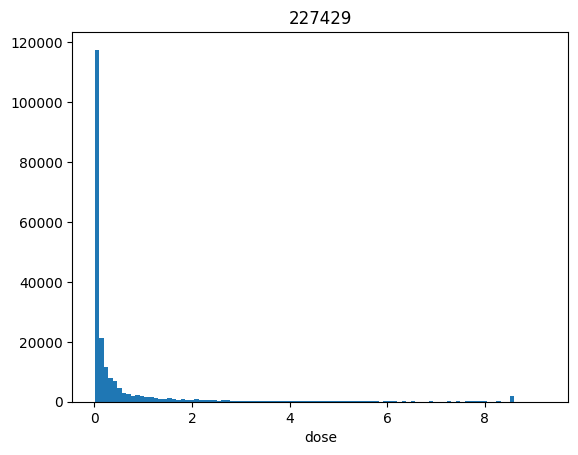

In [64]:
labs = ['227429'] # troponin-T
for lab in labs:
    values = icu_events_df[icu_events_df[lab] > 0][lab]
    print(f"{lab}: median={values.median():.2f}, p25={values.quantile(0.25):.2f}, p75={values.quantile(0.75):.2f}, p90={values.quantile(0.90):.2f}")
    plt.figure()
    plt.hist(values, bins=100)
    plt.title(lab)
    plt.xlabel('dose')
    plt.show()

221794: median=10.03, p25=5.01, p75=20.00, p90=40.00


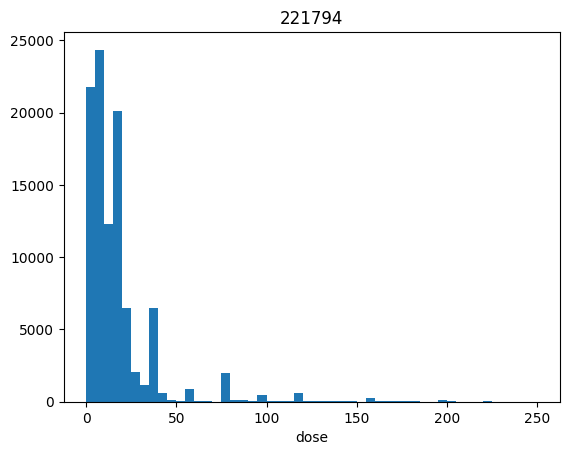

221653: median=17.63, p25=11.10, p75=25.77, p90=34.76


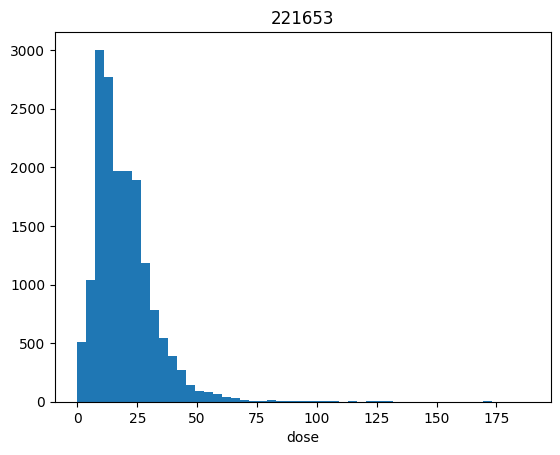

221906: median=0.43, p25=0.21, p75=0.87, p90=1.50


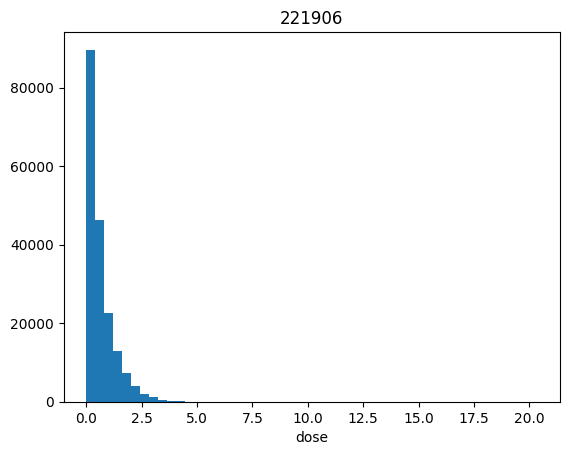

222056: median=4.01, p25=1.95, p75=7.72, p90=12.35


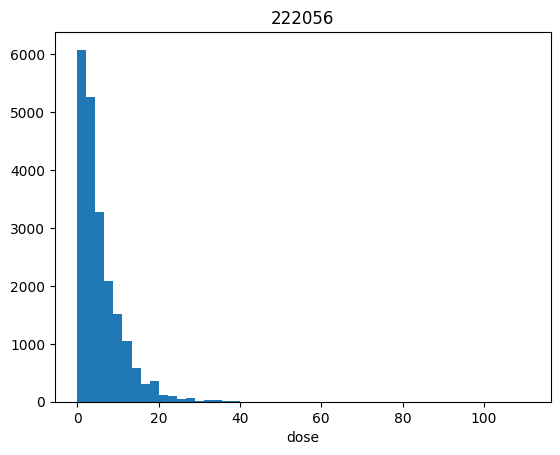

221986: median=1.38, p25=0.92, p75=1.98, p90=2.48


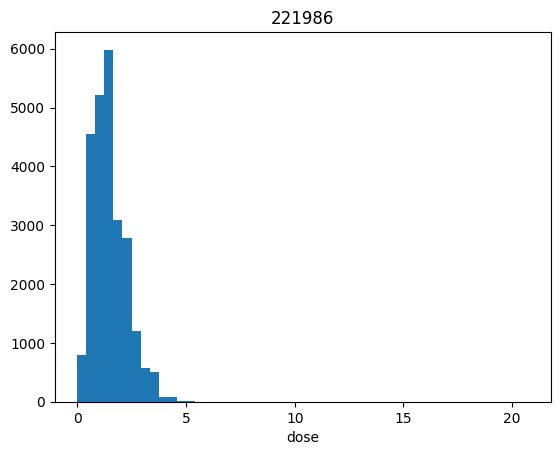

In [65]:
drugs = ['221794', '221653', '221906', '222056', '221986'] # Furosemide, Dobutamine, Norepinephrine, Nitroglycerin, Milrinone
for drug in drugs:
    values = icu_events_df[icu_events_df[drug] > 0][drug]
    print(f"{drug}: median={values.median():.2f}, p25={values.quantile(0.25):.2f}, p75={values.quantile(0.75):.2f}, p90={values.quantile(0.90):.2f}")
    plt.figure()
    plt.hist(values, bins=50)
    plt.title(drug)
    plt.xlabel('dose')
    plt.show()

In [66]:
ts_dataset['Edema'].value_counts()

Edema
0.0    35162
1.0    16907
Name: count, dtype: int64

In [ ]:
test = ts_dataset.copy()

mask = test['Edema'] == 1.0
silver_results = test.loc[mask].apply(silver_standard_for_edema, axis=1)

# Edema=1인 행에만 값 할당
test.loc[mask, 'subtype_label'] = silver_results['label']
test.loc[mask, 'cpe_score'] = silver_results['cpe_score']
test.loc[mask, 'ncpe_score'] = silver_results['ncpe_score']
test.loc[mask, 'score_diff'] = silver_results['score_diff']

print(test['subtype_label'].value_counts(dropna=False))

In [69]:
ts_dataset

,hadm_id,stay_id,hour_slot,50963,220045,220179,220180,220210,220277,220546,220615,220645,223761,223835,225624,225668,227073,227429,227442,227445,227446,227456,spo2_fio2,bun_creatinine,221653,221662,221749,221794,221906,221986,222051,222056,225168,225974,fluid_alb,fluid_cyst,225402,225794,urine,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardiomediastinum,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices
0,20001305,36916968,0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.000000,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.000000,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,20001305,36916968,1,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,12.6,-2.0,-2.0,-2.000000,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.000000,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,20001305,36916968,2,-2.0,76.0,89.0,36.0,18.0,100.0,12.6,-2.0,-2.0,36.833333,0.5,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,200.000000,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2002.891291,0.0,0.0,14.787500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,20001305,36916968,3,-2.0,73.0,79.0,40.0,25.0,100.0,12.6,-2.0,-2.0,36.833333,0.5,-2.0,2.3,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,200.000000,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2004.206426,0.0,0.0,0.212500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,20001305,36916968,4,-2.0,66.0,88.0,45.0,20.0,100.0,12.6,-2.0,-2.0,36.833333,0.5,-2.0,2.3,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,200.000000,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.111092,0.0,0.0,18.716667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1618766,29999098,33475199,261,-2.0,63.0,-2.0,-2.0,16.0,95.0,22.8,1.0,153.0,36.722222,0.6,20.0,1.3,16.0,-2.0,3.4,-2.0,-2.0,2.8,158.333333,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,82.203390,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1618767,29999098,33475199,262,-2.0,69.0,-2.0,-2.0,16.0,97.0,22.8,1.0,153.0,36.444444,0.7,20.0,1.3,16.0,-2.0,3.4,-2.0,-2.0,2.8,138.571429,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,100.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1618768,29999098,33475199,263,-2.0,68.0,-2.0,-2.0,16.0,96.0,22.8,1.0,153.0,36.444444,0.7,20.0,1.3,16.0,-2.0,3.4,-2.0,-2.0,2.8,137.142857,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,114.406780,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1618769,29999098,33475199,264,-2.0,69.0,-2.0,-2.0,16.0,94.0,22.8,1.0,153.0,36.444444,0.7,20.0,1.3,16.0,-2.0,3.4,-2.0,-2.0,2.8,134.285714,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,106.779661,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [68]:
test[mask]['cpe_score'].describe()

KeyError: 'cpe_score'

In [ ]:
test[mask]['ncpe_score'].describe()

count    12411.000000
mean         1.102409
std          1.382901
min          0.000000
25%          0.000000
50%          0.500000
75%          1.500000
max          5.750000
Name: ncpe_score, dtype: float64

- 주요 라벨링 분포 지표

In [ ]:
analysis_df = test[test["Edema"]==1]
analysis_df = analysis_df[['stay_id', 'hour_slot', 'Edema', 'subtype_label', 'cpe_score', 'ncpe_score', 'score_diff']].reset_index(drop=True)

In [ ]:
test.groupby('subtype_label')[['cpe_score','ncpe_score','score_diff']].mean()

,cpe_score,ncpe_score,score_diff
subtype_label,,,
0.0,2.771978,2.792582,-0.020604
1.0,0.439254,2.826765,-2.387511
2.0,3.165109,0.521223,2.643886


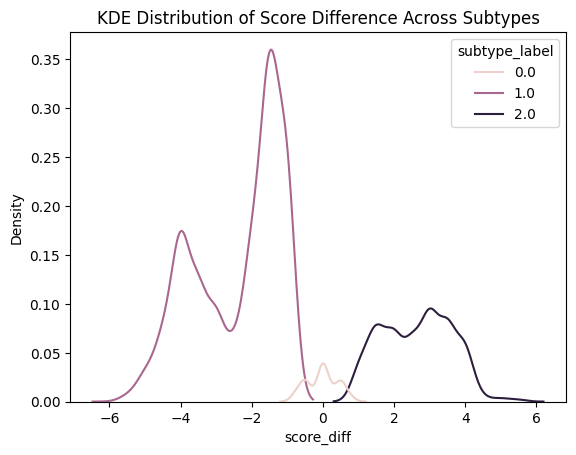

In [ ]:
sns.kdeplot(data=test, x="score_diff", hue="subtype_label")
plt.title("KDE Distribution of Score Difference Across Subtypes")
plt.show()

In [ ]:
itemid_df = pd.read_parquet("/home/DAHS1/gangmin/my_research/data/mimic-iv/icu/parquet/d_items.parquet")
itemid_df['itemid'] = itemid_df['itemid'].astype(str)

analysis_df = test[(test['Edema'] == 1) & (test['subtype_label'].notna())].copy()

FEATURES = [
    '227446','50963','227445', 'bun_creatinine', '227429',
    'spo2_fio2', '223835', '227456', '223761',
]

def compute_group_stats(df, features):
    rows = []
    for f in features:
        if f not in df.columns:
            continue
        
        valid = df[df[f] != -2]
        
        for label in [0.0, 1.0, 2.0]:
            sub = valid[valid['subtype_label'] == label]
            rows.append({
                "feature": f,
                "label": label,
                "median": sub[f].median(),
                "mean": sub[f].mean(),
                "n": len(sub)
            })
    
    return pd.DataFrame(rows)

stats_df = compute_group_stats(analysis_df, FEATURES)
stats_pivot = stats_df.pivot(index='feature', columns='label', values='median')

stats_pivot = stats_pivot.merge(
    itemid_df[['itemid', 'label']].rename(columns={'itemid': 'feature'}),
    on='feature',
    how='left'
)

stats_pivot = stats_pivot[['feature', 'label'] + [col for col in stats_pivot.columns if col not in ['feature', 'label']]]
stats_pivot

,feature,label,0.0,1.0,2.0
0,223761,Temperature Fahrenheit,36.888889,37.000000,36.888889
1,223835,Inspired O2 Fraction,0.600000,0.600000,0.400000
2,227429,Troponin-T,1.020000,0.070000,0.640000
3,227445,CK-MB,12.166667,5.000000,6.000000
4,227446,Brain Natiuretic Peptide (BNP),6705.000000,1847.000000,6836.000000
5,227456,Albumin,3.000000,2.900000,3.100000
6,50963,NaN,5432.000000,1924.500000,7478.000000
7,bun_creatinine,NaN,23.636364,20.000000,24.226190
8,spo2_fio2,NaN,165.000000,163.333333,240.000000


In [ ]:
test.groupby('subtype_label')['score_diff'].describe(percentiles=[.01,.05,.1,.25,.5,.75,.9,.95,.99])

,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
subtype_label,,,,,,,,,,,,,,
0.0,182.0,-0.020604,0.422831,-0.75,-0.75,-0.75,-0.5,-0.50,0.00,0.25,0.5,0.5,0.75,0.75
1.0,3527.0,-2.387511,1.232470,-5.75,-5.00,-4.50,-4.0,-3.50,-2.00,-1.50,-1.0,-1.0,-1.00,-1.00
2.0,1284.0,2.643886,0.971427,1.00,1.00,1.00,1.5,1.75,2.75,3.50,4.0,4.0,5.00,5.50


In [ ]:
print("Level 1 Label distritubion")
print(test['Edema'].value_counts(dropna=False))

print("\nLevel 2 Label distritubion")
print(test['subtype_label'].value_counts(dropna=False))

Level 1 Label distritubion
Edema
 NaN    1565474
 0.0      36390
 1.0      12411
-1.0       4496
Name: count, dtype: int64

Level 2 Label distritubion
subtype_label
NaN    1613778
1.0       3527
2.0       1284
0.0        182
Name: count, dtype: int64


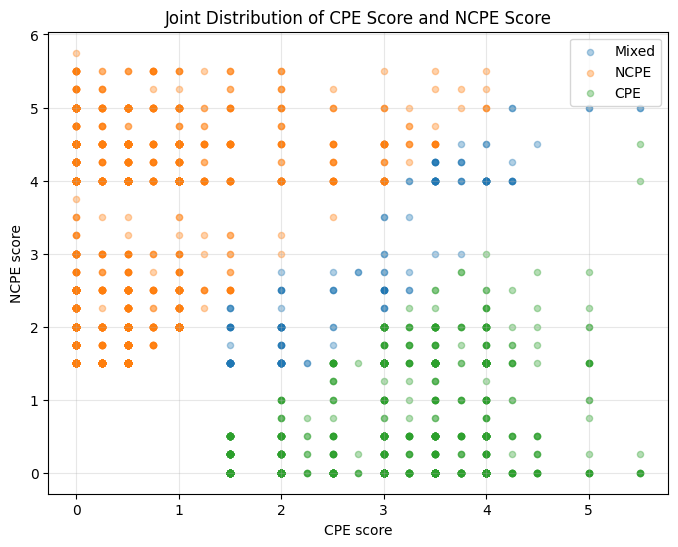

In [ ]:
def plot_joint_distribution_scatter(df, label_col='label',
                                    cpe_col='cpe_score',
                                    ncpe_col='ncpe_score'):
    plot_df = df[[label_col, cpe_col, ncpe_col]].dropna().copy()

    label_map = {
        0.0: 'Mixed',
        1.0: 'NCPE',
        2.0: 'CPE'
    }
    plot_df['label_name'] = plot_df[label_col].map(label_map)

    plt.figure(figsize=(8, 6))

    for label_value, label_name in label_map.items():
        sub = plot_df[plot_df[label_col] == label_value]
        if len(sub) == 0:
            continue
        plt.scatter(
            sub[cpe_col],
            sub[ncpe_col],
            alpha=0.35,
            s=20,
            label=label_name
        )

    plt.xlabel('CPE score')
    plt.ylabel('NCPE score')
    plt.title('Joint Distribution of CPE Score and NCPE Score')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_joint_distribution_scatter(test, label_col='subtype_label', cpe_col='cpe_score', ncpe_col='ncpe_score')

In [ ]:
def intermediate_progression_analysis(df, stay_col='stay_id', time_col='hour_slot', label_col='label', intermediate_label=0.0):
    temp = df[[stay_col, time_col, label_col]].dropna().copy()
    temp = temp.sort_values([stay_col, time_col])

    results = []

    for stay_id, sub in temp.groupby(stay_col):
        sub = sub.sort_values(time_col)
        labels = sub[label_col].tolist()

        if intermediate_label not in labels:
            continue

        first_intermediate_idx = labels.index(intermediate_label)
        later_labels = labels[first_intermediate_idx + 1:]

        progressed_to = 'stayed_or_unknown'
        if 2.0 in later_labels:
            progressed_to = 'to_CPE'
        elif 1.0 in later_labels:
            progressed_to = 'to_NCPE'

        results.append({
            stay_col: stay_id,
            'progression': progressed_to
        })

    result_df = pd.DataFrame(results)

    summary = (
        result_df['progression']
        .value_counts(dropna=False)
        .reset_index()
    )
    summary.columns = ['progression', 'count']
    summary['proportion'] = summary['count'] / summary['count'].sum()

    return result_df, summary

progression_df, progression_summary = intermediate_progression_analysis(test, label_col='subtype_label')
progression_summary

,progression,count,proportion
0,to_CPE,72,0.496552
1,stayed_or_unknown,55,0.379310
2,to_NCPE,18,0.124138


In [ ]:
progression_df

,stay_id,progression
0,30109454,stayed_or_unknown
1,30129989,to_NCPE
2,30340121,to_NCPE
3,30397772,stayed_or_unknown
4,30509159,to_NCPE
...,...,...
140,39793956,to_CPE
141,39820699,to_CPE
142,39865725,to_CPE
143,39902669,to_CPE


---

## 데이터 최종 전처리 부분

In [ ]:
labeled_ts_dataset = test.copy()
labeled_ts_dataset

In [45]:
labeled_ts_dataset.columns

Index(['hadm_id', 'stay_id', 'hour_slot', 'slot_start', 'slot_end', 'cxr_flag',
       'image_path', 'cxrtime', 'Atelectasis', 'Cardiomegaly', 'Consolidation',
       'Edema', 'Enlarged Cardiomediastinum', 'Fracture', 'Lung Lesion',
       'Lung Opacity', 'No Finding', 'Pleural Effusion', 'Pleural Other',
       'Pneumonia', 'Pneumothorax', 'Support Devices', 'was_missing'],
      dtype='object')

In [46]:
key_id_icu = pd.read_feather("/home/DAHS1/gangmin/my_research/processed/key_id_icu.ftr")
key_id_icu = key_id_icu[['subject_id', 'hadm_id', 'stay_id']]

patient_df = pd.read_parquet("/home/DAHS1/gangmin/my_research/data/mimic-iv/core/parquet/patients.parquet")
patient_df = patient_df[['subject_id', 'gender']]

df_weight = pd.read_feather('/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/2rd_preprocessed_data/df_weight.ftr')
df_weight = df_weight.rename(columns={'valuenum':'weight'})
df_weight = df_weight.drop(columns=['charttime', 'stay_id', 'hadm_id'])
subject_weight = df_weight.groupby('subject_id')['weight'].mean().reset_index()

demo_df = key_id_icu.merge(patient_df, how='left', on=['subject_id'])
demo_df = demo_df.merge(subject_weight, how='left', on=['subject_id'])
demo_df

,subject_id,hadm_id,stay_id,gender,weight
0,10001884,26184834.0,37510196.0,F,65.000000
1,10002428,23473524.0,35479615.0,F,46.340934
2,10002428,28662225.0,33987268.0,F,46.340934
3,10002428,28662225.0,38875437.0,F,46.340934
4,10003400,20214994.0,32128372.0,F,95.521724
...,...,...,...,...,...
14141,19998330,24096838.0,33428243.0,F,78.670588
14142,19998843,24842066.0,30988867.0,M,72.823529
14143,19999287,20175828.0,35165301.0,F,86.850725
14144,19999442,26785317.0,32336619.0,M,107.393662


In [47]:
# 8개의 subject_id만 weight가 결측임. 
demo_df['weight'].isnull().sum()

# 따라서 그냥 성별별 median 값으로 채우는 것을 선택함.
gender_median = demo_df.groupby('gender')['weight'].median()

# M, F만 확실하다면 get() 없이 바로 접근
print(f"남성 체중 중앙값: {gender_median['M']}")
print(f"여성 체중 중앙값: {gender_median['F']}")

# 결측치 채우기
demo_df['weight'] = demo_df['weight'].fillna(demo_df['gender'].map(gender_median))

labeled_ts_dataset = labeled_ts_dataset.merge(demo_df[['stay_id', 'weight']], how='left', on=['stay_id'])

# Crystalloid / Patient weight
labeled_ts_dataset['cryst_weight'] = labeled_ts_dataset['fluid_cyst'] / labeled_ts_dataset['weight']

남성 체중 중앙값: 83.14565217391304
여성 체중 중앙값: 70.3747663551402


KeyError: 'fluid_cyst'

In [66]:
final_ts_df = labeled_ts_dataset.copy()

In [67]:
final_ts_df.columns

Index(['hadm_id', 'stay_id', 'hour_slot', '50963', '220045', '220179',
       '220180', '220210', '220277', '220546', '220615', '220645', '223761',
       '223835', '225624', '225668', '227073', '227429', '227442', '227445',
       '227446', '227456', 'spo2_fio2', 'bun_creatinine', '221653', '221662',
       '221749', '221794', '221906', '221986', '222051', '222056', '225168',
       '225974', 'fluid_alb', 'fluid_cyst', '225402', '225794', 'urine',
       'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema',
       'Enlarged Cardiomediastinum', 'Fracture', 'Lung Lesion', 'Lung Opacity',
       'No Finding', 'Pleural Effusion', 'Pleural Other', 'Pneumonia',
       'Pneumothorax', 'Support Devices', 'weight', 'cryst_weight'],
      dtype='object')

In [68]:
value_cols = [
    '50963', '220045', '220179',
    '220180', '220210', '220277', '220546', '220615', '220645', '223761',
    '223835', '225624', '225668', '227073', '227429', '227442', '227445',
    '227446', '227456', 'spo2_fio2', 'bun_creatinine', '221653', '221662',
    '221749', '221794', '221906', '221986', '222051', '222056', '225168',
    '225974', 'fluid_alb', 'cryst_weight', '225402', '225794', 'urine', 
]

In [ ]:
# label_cols = [
#     'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Enlarged Cardiomediastinum', 'Fracture', 'Lung Lesion', 'Lung Opacity', 
#     'No Finding', 'Pleural Effusion', 'Pleural Other', 'Pneumonia', 'Pneumothorax', 'Support Devices'
# ]

label_cols = [
    'Edema'
]

In [70]:
df_masks = final_ts_df[['hadm_id', 'stay_id', 'hour_slot'] + value_cols + label_cols]

In [71]:
df_masks = df_masks.merge(key_id_icu, how='left', on=['hadm_id', 'stay_id'])
df_masks = df_masks.sort_values(by=['subject_id', 'hadm_id', 'stay_id', 'hour_slot']).reset_index(drop=True)
df_masks

,hadm_id,stay_id,hour_slot,50963,220045,220179,220180,220210,220277,220546,220615,220645,223761,223835,225624,225668,227073,227429,227442,227445,227446,227456,spo2_fio2,bun_creatinine,221653,221662,221749,221794,221906,221986,222051,222056,225168,225974,fluid_alb,cryst_weight,225402,225794,urine,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardiomediastinum,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices,subject_id
0,26184834,37510196,0,-2.0,49.000000,173.5,30.5,10.000000,98.0,12.2,1.1,130.0,-2.000000,-2.0,27.0,1.7,17.0,0.05,4.500,20.0,-2.0,-2.0,-2.0,24.545455,0.0,14.336044,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.922689,0.0,0.0,0.000000,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10001884
1,26184834,37510196,1,-2.0,72.000000,102.0,63.0,20.000000,100.0,12.2,1.1,130.0,-2.000000,-2.0,27.0,1.7,17.0,0.05,4.500,20.0,-2.0,-2.0,-2.0,24.545455,0.0,19.512196,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.489540,0.0,0.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10001884
2,26184834,37510196,2,-2.0,70.666667,101.5,69.0,17.666667,95.0,18.4,1.1,135.5,35.400000,0.5,30.0,1.5,11.0,0.08,3.975,14.0,-2.0,3.5,190.0,27.272727,0.0,22.905149,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.722716,1.0,0.0,92.048611,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10001884
3,26184834,37510196,3,-2.0,71.000000,102.0,71.0,20.000000,100.0,18.4,1.1,135.5,35.800000,0.5,30.0,1.5,11.0,0.08,3.975,14.0,-2.0,3.5,200.0,27.272727,0.0,29.530504,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.921432,1.0,0.0,215.296022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10001884
4,26184834,37510196,4,-2.0,71.000000,138.0,76.0,20.000000,98.0,18.4,1.1,135.5,36.300000,0.5,30.0,1.5,11.0,0.08,3.975,14.0,-2.0,3.5,196.0,27.272727,0.0,21.831458,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.573820,0.0,0.0,123.782818,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10001884
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1618766,23865745,36195440,42,-2.0,98.000000,152.0,92.0,22.000000,97.0,11.6,1.2,147.0,37.000000,-2.0,22.0,-2.0,11.0,1.13,4.100,38.0,-2.0,-2.0,-2.0,18.333333,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19999987
1618767,23865745,36195440,43,-2.0,98.000000,152.0,92.0,22.000000,97.0,11.6,1.2,147.0,37.000000,-2.0,22.0,-2.0,11.0,1.13,4.100,38.0,-2.0,-2.0,-2.0,18.333333,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19999987
1618768,23865745,36195440,44,-2.0,93.000000,163.0,120.0,20.000000,100.0,11.6,1.2,147.0,37.000000,-2.0,22.0,-2.0,11.0,-2.00,4.100,-2.0,-2.0,-2.0,-2.0,18.333333,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,303.333333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19999987
1618769,23865745,36195440,45,-2.0,92.000000,163.0,120.0,23.000000,100.0,11.6,1.2,147.0,37.833333,-2.0,22.0,-2.0,11.0,-2.00,4.100,-2.0,-2.0,-2.0,-2.0,18.333333,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.679778,0.0,0.0,21.666667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19999987


In [ ]:
from preprocess.scaling_functions import (
    feature_specific_scaling_fit,
    feature_specific_scaling_transform,
    create_precise_flags,
    save_scaling_stats,
    load_scaling_stats
)

# from preprocess.split_functions import split_by_stay_id
from preprocess.split_functions import split_by_subject_stratified # 층화추출 다시 고민해 봐야 함.

In [73]:
itemid_df = pd.read_parquet("/home/DAHS1/gangmin/my_research/data/mimic-iv/icu/parquet/d_items.parquet")

# procedure는 정규화 대상에서 제외해야 함.
no_proc_feature_cols = [
    '50963', '220045', '220179',
    '220180', '220210', '220277', '220546', '220615', '220645', '223761',
    '223835', '225624', '225668', '227073', '227429', '227442', '227445',
    '227446', '227456', 'spo2_fio2', 'bun_creatinine', '221653', '221662',
    '221749', '221794', '221906', '221986', '222051', '222056', '225168',
    '225974', 'fluid_alb', 'cryst_weight', 'urine', 
]

# 파생변수나 lab은 안 보임.
itemid_df['itemid'] = itemid_df['itemid'].astype(str)
itemid_df[itemid_df['itemid'].isin(no_proc_feature_cols)].reset_index(drop=True)

,itemid,label,abbreviation,linksto,category,unitname,param_type,lownormalvalue,highnormalvalue
0,220045,Heart Rate,HR,chartevents,Routine Vital Signs,bpm,Numeric,NaN,NaN
1,220179,Non Invasive Blood Pressure systolic,NBPs,chartevents,Routine Vital Signs,mmHg,Numeric,NaN,NaN
2,220180,Non Invasive Blood Pressure diastolic,NBPd,chartevents,Routine Vital Signs,mmHg,Numeric,NaN,NaN
3,220210,Respiratory Rate,RR,chartevents,Respiratory,insp/min,Numeric,NaN,NaN
4,220277,O2 saturation pulseoxymetry,SpO2,chartevents,Respiratory,%,Numeric,NaN,NaN
5,220546,WBC,WBC,chartevents,Labs,None,Numeric,NaN,NaN
6,220615,Creatinine (serum),Creatinine (serum),chartevents,Labs,None,Numeric,NaN,NaN
7,220645,Sodium (serum),Sodium (serum),chartevents,Labs,None,Numeric,NaN,NaN
8,221653,Dobutamine,Dobutamine,inputevents,Medications,mg,Solution,NaN,NaN
9,221662,Dopamine,Dopamine,inputevents,Medications,mg,Solution,NaN,NaN


In [74]:
df_masks.to_feather('/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/2rd_preprocessed_data/processed/df_masks_20260428_all_label.ftr')

---

In [ ]:
# df_masks = pd.read_feather('/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/2rd_preprocessed_data/processed/df_masks_20260428.ftr')

In [76]:
df_masks

,hadm_id,stay_id,hour_slot,50963,220045,220179,220180,220210,220277,220546,220615,220645,223761,223835,225624,225668,227073,227429,227442,227445,227446,227456,spo2_fio2,bun_creatinine,221653,221662,221749,221794,221906,221986,222051,222056,225168,225974,fluid_alb,cryst_weight,225402,225794,urine,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardiomediastinum,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices,subject_id
0,26184834,37510196,0,-2.0,49.000000,173.5,30.5,10.000000,98.0,12.2,1.1,130.0,-2.000000,-2.0,27.0,1.7,17.0,0.05,4.500,20.0,-2.0,-2.0,-2.0,24.545455,0.0,14.336044,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.922689,0.0,0.0,0.000000,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10001884
1,26184834,37510196,1,-2.0,72.000000,102.0,63.0,20.000000,100.0,12.2,1.1,130.0,-2.000000,-2.0,27.0,1.7,17.0,0.05,4.500,20.0,-2.0,-2.0,-2.0,24.545455,0.0,19.512196,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.489540,0.0,0.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10001884
2,26184834,37510196,2,-2.0,70.666667,101.5,69.0,17.666667,95.0,18.4,1.1,135.5,35.400000,0.5,30.0,1.5,11.0,0.08,3.975,14.0,-2.0,3.5,190.0,27.272727,0.0,22.905149,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.722716,1.0,0.0,92.048611,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10001884
3,26184834,37510196,3,-2.0,71.000000,102.0,71.0,20.000000,100.0,18.4,1.1,135.5,35.800000,0.5,30.0,1.5,11.0,0.08,3.975,14.0,-2.0,3.5,200.0,27.272727,0.0,29.530504,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.921432,1.0,0.0,215.296022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10001884
4,26184834,37510196,4,-2.0,71.000000,138.0,76.0,20.000000,98.0,18.4,1.1,135.5,36.300000,0.5,30.0,1.5,11.0,0.08,3.975,14.0,-2.0,3.5,196.0,27.272727,0.0,21.831458,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.573820,0.0,0.0,123.782818,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10001884
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1618766,23865745,36195440,42,-2.0,98.000000,152.0,92.0,22.000000,97.0,11.6,1.2,147.0,37.000000,-2.0,22.0,-2.0,11.0,1.13,4.100,38.0,-2.0,-2.0,-2.0,18.333333,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19999987
1618767,23865745,36195440,43,-2.0,98.000000,152.0,92.0,22.000000,97.0,11.6,1.2,147.0,37.000000,-2.0,22.0,-2.0,11.0,1.13,4.100,38.0,-2.0,-2.0,-2.0,18.333333,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19999987
1618768,23865745,36195440,44,-2.0,93.000000,163.0,120.0,20.000000,100.0,11.6,1.2,147.0,37.000000,-2.0,22.0,-2.0,11.0,-2.00,4.100,-2.0,-2.0,-2.0,-2.0,18.333333,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,303.333333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19999987
1618769,23865745,36195440,45,-2.0,92.000000,163.0,120.0,23.000000,100.0,11.6,1.2,147.0,37.833333,-2.0,22.0,-2.0,11.0,-2.00,4.100,-2.0,-2.0,-2.0,-2.0,18.333333,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.679778,0.0,0.0,21.666667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19999987


In [75]:
ones = df_masks[label_cols].sum()
zeros = len(df_masks) - ones

label_summary = pd.DataFrame({'Positive label': ones})
label_summary.sort_values(by="Positive label", ascending=False)

,Positive label
Support Devices,35371.0
Pleural Effusion,23364.0
Atelectasis,20142.0
Cardiomegaly,19451.0
Lung Opacity,18513.0
Edema,16907.0
Pneumonia,8809.0
Enlarged Cardiomediastinum,7053.0
No Finding,6751.0
Consolidation,6314.0


In [77]:
vital_cols = ['220045', '220179', '220180', '220210', '223761', 'spo2_fio2', '220277', '223835']
input_cols = ['221653', '221662', '221749', '221794', '221906', '221986', '222051', '222056', '225168', '225974']
urine_fluid_cols = ['urine', 'fluid_alb', 'cryst_weight']
lab_cols = ['225624', '220645', '227073', '227429', '227442', '227445', '227446', '227456', '50963', '220546', '220615', '225668', 'bun_creatinine']
proc_cols = ['225402', '225794']

meta_cols = ['subject_id', 'hadm_id', 'stay_id', 'hour_slot', 'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Enlarged Cardiomediastinum', 'Fracture', 'Lung Lesion', 'Lung Opacity', 'No Finding', 'Pleural Effusion', 'Pleural Other', 'Pneumonia', 'Pneumothorax', 'Support Devices']

In [78]:
selected_cols = meta_cols + vital_cols + lab_cols + urine_fluid_cols + proc_cols

df_masks = df_masks[selected_cols]

In [79]:
df_masks

,subject_id,hadm_id,stay_id,hour_slot,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardiomediastinum,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices,220045,220179,220180,220210,223761,spo2_fio2,220277,223835,225624,220645,227073,227429,227442,227445,227446,227456,50963,220546,220615,225668,bun_creatinine,urine,fluid_alb,cryst_weight,225402,225794
0,10001884,26184834,37510196,0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,49.000000,173.5,30.5,10.000000,-2.000000,-2.0,98.0,-2.0,27.0,130.0,17.0,0.05,4.500,20.0,-2.0,-2.0,-2.0,12.2,1.1,1.7,24.545455,0.000000,0.0,1.922689,0.0,0.0
1,10001884,26184834,37510196,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,72.000000,102.0,63.0,20.000000,-2.000000,-2.0,100.0,-2.0,27.0,130.0,17.0,0.05,4.500,20.0,-2.0,-2.0,-2.0,12.2,1.1,1.7,24.545455,0.000000,0.0,0.489540,0.0,0.0
2,10001884,26184834,37510196,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.666667,101.5,69.0,17.666667,35.400000,190.0,95.0,0.5,30.0,135.5,11.0,0.08,3.975,14.0,-2.0,3.5,-2.0,18.4,1.1,1.5,27.272727,92.048611,0.0,0.722716,1.0,0.0
3,10001884,26184834,37510196,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,71.000000,102.0,71.0,20.000000,35.800000,200.0,100.0,0.5,30.0,135.5,11.0,0.08,3.975,14.0,-2.0,3.5,-2.0,18.4,1.1,1.5,27.272727,215.296022,0.0,3.921432,1.0,0.0
4,10001884,26184834,37510196,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,71.000000,138.0,76.0,20.000000,36.300000,196.0,98.0,0.5,30.0,135.5,11.0,0.08,3.975,14.0,-2.0,3.5,-2.0,18.4,1.1,1.5,27.272727,123.782818,0.0,0.573820,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1618766,19999987,23865745,36195440,42,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,98.000000,152.0,92.0,22.000000,37.000000,-2.0,97.0,-2.0,22.0,147.0,11.0,1.13,4.100,38.0,-2.0,-2.0,-2.0,11.6,1.2,-2.0,18.333333,0.000000,0.0,0.000000,0.0,0.0
1618767,19999987,23865745,36195440,43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,98.000000,152.0,92.0,22.000000,37.000000,-2.0,97.0,-2.0,22.0,147.0,11.0,1.13,4.100,38.0,-2.0,-2.0,-2.0,11.6,1.2,-2.0,18.333333,0.000000,0.0,0.000000,0.0,0.0
1618768,19999987,23865745,36195440,44,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,93.000000,163.0,120.0,20.000000,37.000000,-2.0,100.0,-2.0,22.0,147.0,11.0,-2.00,4.100,-2.0,-2.0,-2.0,-2.0,11.6,1.2,-2.0,18.333333,303.333333,0.0,0.000000,0.0,0.0
1618769,19999987,23865745,36195440,45,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,92.000000,163.0,120.0,23.000000,37.833333,-2.0,100.0,-2.0,22.0,147.0,11.0,-2.00,4.100,-2.0,-2.0,-2.0,-2.0,11.6,1.2,-2.0,18.333333,21.666667,0.0,2.679778,0.0,0.0


In [80]:
# 1. Split 먼저 수행 (patient-level stratified)
print("\n" + "="*80)
print("STEP 1: Patient-level Stratified Split")
print("="*80)

# train_ts_raw, val_ts_raw, test_ts_raw = split_by_stay_id(
#     df_masks,
#     train_ratio=0.7,
#     val_ratio=0.15,
#     random_seed=42
# )

train_ts_raw, val_ts_raw, test_ts_raw = split_by_subject_stratified(
    df_masks,
    train_ratio=0.8,
    val_ratio=0.1,
    random_seed=42
)


STEP 1: Patient-level Stratified Split

[Dataset Split] Subject-level random split (no label stratification):
  Train: 8,684 subjects / 1,289,557 rows  (80.0%)
  Val:   1,085 subjects / 160,744 rows  (10.0%)
  Test:  1,086 subjects / 168,470 rows  (10.0%)
  [OK] No subject overlap between splits



In [81]:
# 2. Scaling with Train Statistics
print("\n" + "="*80)
print("STEP 2: Scaling with Train Statistics")
print("="*80)

train_scaled, scaling_stats = feature_specific_scaling_fit(
    train_ts_raw,
    lab_cols=lab_cols,
    input_urine_cols=urine_fluid_cols,
    vital_cols=vital_cols,
    sentinel=-2
)

print(f"✅ Train set scaled. Shape: {train_scaled.shape}")
print(f"✅ Scaling statistics computed for {len(scaling_stats)} columns")


STEP 2: Scaling with Train Statistics
✅ Train set scaled. Shape: (1289557, 44)
✅ Scaling statistics computed for 24 columns


In [82]:
train_scaled

,subject_id,hadm_id,stay_id,hour_slot,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardiomediastinum,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices,220045,220179,220180,220210,223761,spo2_fio2,220277,223835,225624,220645,227073,227429,227442,227445,227446,227456,50963,220546,220615,225668,bun_creatinine,urine,fluid_alb,cryst_weight,225402,225794
0,10001884,26184834,37510196,0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2.131779,2.433486,-2.150174,-1.801531,-2.000000,-2.000000,0.335223,-2.000000,0.131035,-1.653103,0.729899,-0.489188,0.862212,1.052226,-2.0,-2.000000,-2.0,0.227274,-0.181775,0.071726,0.234776,0.000000,0.0,0.226195,0.0,0.0
1,10001884,26184834,37510196,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.851027,-0.813465,-0.064900,-0.089758,-2.000000,-2.000000,0.900309,-2.000000,0.131035,-1.653103,0.729899,-0.489188,0.862212,1.052226,-2.0,-2.000000,-2.0,0.227274,-0.181775,0.071726,0.234776,0.000000,0.0,-0.377140,0.0,0.0
2,10001884,26184834,37510196,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.925273,-0.836171,0.320074,-0.489172,-2.835093,-0.618411,-0.512406,0.215667,0.278892,-0.588956,-0.917397,-0.427989,-0.077486,0.724027,-2.0,0.848077,-2.0,1.007660,-0.181775,-0.148898,0.431466,-0.067542,0.0,-0.278976,1.0,0.0
3,10001884,26184834,37510196,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.906712,-0.813465,0.448398,-0.089758,-2.130897,-0.435984,0.900309,0.215667,0.278892,-0.588956,-0.917397,-0.427989,-0.077486,0.724027,-2.0,0.848077,-2.0,1.007660,-0.181775,-0.148898,0.431466,1.014560,0.0,1.067636,1.0,0.0
4,10001884,26184834,37510196,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.906712,0.821363,0.769210,-0.089758,-1.250652,-0.508955,0.335223,0.215667,0.278892,-0.588956,-0.917397,-0.427989,-0.077486,0.724027,-2.0,0.848077,-2.0,1.007660,-0.181775,-0.148898,0.431466,0.211082,0.0,-0.341659,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1618766,19999987,23865745,36195440,42,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.596779,1.457130,1.795806,0.252596,-0.018308,-2.000000,0.052680,-2.000000,-0.154720,1.503969,-0.917397,1.047443,0.154951,1.656045,-2.0,-2.000000,-2.0,0.132992,-0.071407,-2.000000,-0.305491,0.000000,0.0,0.000000,0.0,0.0
1618767,19999987,23865745,36195440,43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.596779,1.457130,1.795806,0.252596,-0.018308,-2.000000,0.052680,-2.000000,-0.154720,1.503969,-0.917397,1.047443,0.154951,1.656045,-2.0,-2.000000,-2.0,0.132992,-0.071407,-2.000000,-0.305491,0.000000,0.0,0.000000,0.0,0.0
1618768,19999987,23865745,36195440,44,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.318355,1.956661,3.592350,-0.089758,-0.018308,-2.000000,0.900309,-2.000000,-0.154720,1.503969,-0.917397,-2.000000,0.154951,-2.000000,-2.0,-2.000000,-2.0,0.132992,-0.071407,-2.000000,-0.305491,1.787521,0.0,0.000000,0.0,0.0
1618769,19999987,23865745,36195440,45,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.262670,1.956661,3.592350,0.423773,1.448767,-2.000000,0.900309,-2.000000,-0.154720,1.503969,-0.917397,-2.000000,0.154951,-2.000000,-2.0,-2.000000,-2.0,0.132992,-0.071407,-2.000000,-0.305491,-0.685490,0.0,0.544918,0.0,0.0


In [182]:
train_scaled.columns

Index(['subject_id', 'hadm_id', 'stay_id', 'hour_slot', 'Atelectasis',
       'Cardiomegaly', 'Consolidation', 'Edema', 'Enlarged Cardiomediastinum',
       'Fracture', 'Lung Lesion', 'Lung Opacity', 'No Finding',
       'Pleural Effusion', 'Pleural Other', 'Pneumonia', 'Pneumothorax',
       'Support Devices', '220045', '220179', '220180', '220210', '223761',
       'spo2_fio2', '220277', '223835', '225624', '220645', '227073', '227429',
       '227442', '227445', '227446', '227456', '50963', '220546', '220615',
       '225668', 'bun_creatinine', 'urine', 'fluid_alb', 'cryst_weight',
       '225402', '225794'],
      dtype='object')

In [84]:
len(train_scaled.columns)

44

In [83]:
print("\nTransforming val set with train statistics")
val_scaled = feature_specific_scaling_transform(val_ts_raw, scaling_stats, sentinel=-2)
print(f"✅ Val set scaled. Shape: {val_scaled.shape}")

print("\nTransforming test set with train statistics")
test_scaled = feature_specific_scaling_transform(test_ts_raw, scaling_stats, sentinel=-2)
print(f"✅ Test set scaled. Shape: {test_scaled.shape}")


Transforming val set with train statistics
✅ Val set scaled. Shape: (160744, 44)

Transforming test set with train statistics
✅ Test set scaled. Shape: (168470, 44)


In [85]:
# 3. Create Precise Flags
print("\n" + "="*80)
print("STEP 3: Creating Precise Flags")
print("="*80)

print("Creating flags for train set")
train_with_flags = create_precise_flags(
    df_raw=train_ts_raw,
    df_scaled=train_scaled,
    io_cols=urine_fluid_cols,
    procedure_cols=proc_cols,
    meta_cols=meta_cols,
    sentinel=-2
)

print(f"✅ Train with flags. Shape: {train_with_flags.shape}")
print(f"   Columns: {len(train_with_flags.columns)} (original: {len(train_scaled.columns)})")


STEP 3: Creating Precise Flags
Creating flags for train set
✅ Train with flags. Shape: (1289557, 65)
   Columns: 65 (original: 44)


In [86]:
train_with_flags

,subject_id,hadm_id,stay_id,hour_slot,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardiomediastinum,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices,220045,220045_flag,220179,220179_flag,220180,220180_flag,220210,220210_flag,223761,223761_flag,spo2_fio2,spo2_fio2_flag,220277,220277_flag,223835,223835_flag,225624,225624_flag,220645,220645_flag,227073,227073_flag,227429,227429_flag,227442,227442_flag,227445,227445_flag,227446,227446_flag,227456,227456_flag,50963,50963_flag,220546,220546_flag,220615,220615_flag,225668,225668_flag,bun_creatinine,bun_creatinine_flag,urine,fluid_alb,cryst_weight,225402,225794
0,10001884,26184834,37510196,0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2.131779,1.0,2.433486,1.0,-2.150174,1.0,-1.801531,1.0,0.000000,0.0,0.000000,0.0,0.335223,1.0,0.000000,0.0,0.131035,1.0,-1.653103,1.0,0.729899,1.0,-0.489188,1.0,0.862212,1.0,1.052226,1.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.227274,1.0,-0.181775,1.0,0.071726,1.0,0.234776,1.0,0.000000,0.0,0.226195,0.0,0.0
1,10001884,26184834,37510196,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.851027,1.0,-0.813465,1.0,-0.064900,1.0,-0.089758,1.0,0.000000,0.0,0.000000,0.0,0.900309,1.0,0.000000,0.0,0.131035,1.0,-1.653103,1.0,0.729899,1.0,-0.489188,1.0,0.862212,1.0,1.052226,1.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.227274,1.0,-0.181775,1.0,0.071726,1.0,0.234776,1.0,0.000000,0.0,-0.377140,0.0,0.0
2,10001884,26184834,37510196,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.925273,1.0,-0.836171,1.0,0.320074,1.0,-0.489172,1.0,-2.835093,1.0,-0.618411,1.0,-0.512406,1.0,0.215667,1.0,0.278892,1.0,-0.588956,1.0,-0.917397,1.0,-0.427989,1.0,-0.077486,1.0,0.724027,1.0,0.0,0.0,0.848077,1.0,0.0,0.0,1.007660,1.0,-0.181775,1.0,-0.148898,1.0,0.431466,1.0,-0.067542,0.0,-0.278976,1.0,0.0
3,10001884,26184834,37510196,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.906712,1.0,-0.813465,1.0,0.448398,1.0,-0.089758,1.0,-2.130897,1.0,-0.435984,1.0,0.900309,1.0,0.215667,1.0,0.278892,1.0,-0.588956,1.0,-0.917397,1.0,-0.427989,1.0,-0.077486,1.0,0.724027,1.0,0.0,0.0,0.848077,1.0,0.0,0.0,1.007660,1.0,-0.181775,1.0,-0.148898,1.0,0.431466,1.0,1.014560,0.0,1.067636,1.0,0.0
4,10001884,26184834,37510196,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.906712,1.0,0.821363,1.0,0.769210,1.0,-0.089758,1.0,-1.250652,1.0,-0.508955,1.0,0.335223,1.0,0.215667,1.0,0.278892,1.0,-0.588956,1.0,-0.917397,1.0,-0.427989,1.0,-0.077486,1.0,0.724027,1.0,0.0,0.0,0.848077,1.0,0.0,0.0,1.007660,1.0,-0.181775,1.0,-0.148898,1.0,0.431466,1.0,0.211082,0.0,-0.341659,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1618766,19999987,23865745,36195440,42,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.596779,1.0,1.457130,1.0,1.795806,1.0,0.252596,1.0,-0.018308,1.0,0.000000,0.0,0.052680,1.0,0.000000,0.0,-0.154720,1.0,1.503969,1.0,-0.917397,1.0,1.047443,1.0,0.154951,1.0,1.656045,1.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.132992,1.0,-0.071407,1.0,0.000000,0.0,-0.305491,1.0,0.000000,0.0,0.000000,0.0,0.0
1618767,19999987,23865745,36195440,43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.596779,1.0,1.457130,1.0,1.795806,1.0,0.252596,1.0,-0.018308,1.0,0.000000,0.0,0.052680,1.0,0.000000,0.0,-0.154720,1.0,1.503969,1.0,-0.917397,1.0,1.047443,1.0,0.154951,1.0,1.656045,1.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.132992,1.0,-0.071407,1.0,0.000000,0.0,-0.305491,1.0,0.000000,0.0,0.000000,0.0,0.0
1618768,19999987,23865745,36195440,44,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.318355,1.0,1.956661,1.0,3.592350,1.0,-0.089758,1.0,-0.018308,1.0,0.000000,0.0,0.900309,1.0,0.000000,0.0,-0.154720,1.0,1.503969,1.0,-0.917397,1.0,0.000000,0.0,0.154951,1.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.1329

In [87]:
len(train_with_flags.columns) - len(meta_cols)

47

In [88]:
train_with_flags.columns

Index(['subject_id', 'hadm_id', 'stay_id', 'hour_slot', 'Atelectasis',
       'Cardiomegaly', 'Consolidation', 'Edema', 'Enlarged Cardiomediastinum',
       'Fracture', 'Lung Lesion', 'Lung Opacity', 'No Finding',
       'Pleural Effusion', 'Pleural Other', 'Pneumonia', 'Pneumothorax',
       'Support Devices', '220045', '220045_flag', '220179', '220179_flag',
       '220180', '220180_flag', '220210', '220210_flag', '223761',
       '223761_flag', 'spo2_fio2', 'spo2_fio2_flag', '220277', '220277_flag',
       '223835', '223835_flag', '225624', '225624_flag', '220645',
       '220645_flag', '227073', '227073_flag', '227429', '227429_flag',
       '227442', '227442_flag', '227445', '227445_flag', '227446',
       '227446_flag', '227456', '227456_flag', '50963', '50963_flag', '220546',
       '220546_flag', '220615', '220615_flag', '225668', '225668_flag',
       'bun_creatinine', 'bun_creatinine_flag', 'urine', 'fluid_alb',
       'cryst_weight', '225402', '225794'],
      dtype='object'

In [89]:
print("\nCreating flags for val set...")
val_with_flags = create_precise_flags(
    df_raw=val_ts_raw,
    df_scaled=val_scaled,
    io_cols=urine_fluid_cols,
    procedure_cols=proc_cols,
    meta_cols=meta_cols,
    sentinel=-2
)
print(f"✅ Val with flags. Shape: {val_with_flags.shape}")

print("\nCreating flags for test set...")
test_with_flags = create_precise_flags(
    df_raw=test_ts_raw,
    df_scaled=test_scaled,
    io_cols=urine_fluid_cols,
    procedure_cols=proc_cols,
    meta_cols=meta_cols,
    sentinel=-2
)
print(f"✅ Test with flags. Shape: {test_with_flags.shape}")


Creating flags for val set...
✅ Val with flags. Shape: (160744, 65)

Creating flags for test set...
✅ Test with flags. Shape: (168470, 65)


In [32]:
# output_dir = '/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/3rd_preprocessed_data/'

# train_with_flags.to_feather(output_dir + 'train_multimodal_20260428_ssl.ftr')
# print(f"✅ Saved: {output_dir}train_multimodal_20260428_ssl.ftr")

# val_with_flags.to_feather(output_dir + 'val_multimodal_20260428_ssl.ftr')
# print(f"✅ Saved: {output_dir}val_multimodal_20260428_ssl.ftr")

# test_with_flags.to_feather(output_dir + 'test_multimodal_20260428_ssl.ftr')
# print(f"✅ Saved: {output_dir}test_multimodal_20260428_ssl.ftr")

In [90]:
# 4. 이미지/텍스트/clinical_prompt left join
print("\n" + "="*80)
print("STEP 3: Joining Image/Text/Clinical Prompt Data")
print("="*80)

# 이미지/텍스트 데이터 로드
img_df = pd.read_feather(root_dir + 'src/test/total_cxr_df_5days_20260316.ftr')
text_df = pd.read_feather(root_dir + 'src/test/final_text_df_20260128.ftr')
clinical_prompt_df = pd.read_feather(root_dir + "clinical_multimodal_learning/data/clinical_prompt_df.ftr")

print("Merging train set")
train_final = (train_with_flags
    .merge(img_df, on=['stay_id', 'hour_slot'], how='left')
    .merge(text_df, on=['stay_id', 'hour_slot'], how='left')
    .merge(clinical_prompt_df[['hadm_id', 'stay_id', 'hour_slot', 'clinical_prompt', 'prompt_id']], 
    on=['hadm_id', 'stay_id', 'hour_slot'], how='left')
)
print(f"✅ Train final shape: {train_final.shape}")


STEP 3: Joining Image/Text/Clinical Prompt Data


Merging train set
✅ Train final shape: (1289557, 71)


In [91]:
print("Merging val set")
val_final = (val_with_flags
    .merge(img_df, on=['stay_id', 'hour_slot'], how='left')
    .merge(text_df, on=['stay_id', 'hour_slot'], how='left')
    .merge(clinical_prompt_df[['hadm_id', 'stay_id', 'hour_slot', 'clinical_prompt', 'prompt_id']], 
    on=['hadm_id', 'stay_id', 'hour_slot'], how='left')
)
print(f"✅ Val final shape: {val_final.shape}")

print("Merging test set")
test_final = (test_with_flags
    .merge(img_df, on=['stay_id', 'hour_slot'], how='left')
    .merge(text_df, on=['stay_id', 'hour_slot'], how='left')
    .merge(clinical_prompt_df[['hadm_id', 'stay_id', 'hour_slot', 'clinical_prompt', 'prompt_id']], 
    on=['hadm_id', 'stay_id', 'hour_slot'], how='left')
)
print(f"✅ Test final shape: {test_final.shape}")

Merging val set
✅ Val final shape: (160744, 71)
Merging test set
✅ Test final shape: (168470, 71)


In [92]:
print("\n" + "="*80)
print("Saving Processed Data")
print("="*80)

output_dir = '/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/2rd_preprocessed_data/processed/'

train_final.to_feather(output_dir + 'train_multimodal_20260428_alllabel.ftr')
print(f"✅ Saved: {output_dir}train_multimodal_20260428_alllabel.ftr")

val_final.to_feather(output_dir + 'val_multimodal_20260428_alllabel.ftr')
print(f"✅ Saved: {output_dir}val_multimodal_20260428_alllabel.ftr")

test_final.to_feather(output_dir + 'test_multimodal_20260428_alllabel.ftr')
print(f"✅ Saved: {output_dir}test_multimodal_20260428_alllabel.ftr")

save_scaling_stats(scaling_stats, output_dir + 'scaling_stats_20260428_alllabel.pkl')

print("\n" + "="*80)
print("✅ ALL PREPROCESSING COMPLETED!")
print("="*80)
print("\n📊 Data Summary:")
print(f"  Train: {len(train_final):,} rows from {train_final['stay_id'].nunique():,} patients")
print(f"  Val:   {len(val_final):,} rows from {val_final['stay_id'].nunique():,} patients")
print(f"  Test:  {len(test_final):,} rows from {test_final['stay_id'].nunique():,} patients")
print(f"\n  Total columns: {len(train_final.columns)}")
print(f"  Feature columns (with flags): {len([c for c in train_final.columns if '_flag' in c or c not in meta_cols])}")



Saving Processed Data
✅ Saved: /home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/2rd_preprocessed_data/processed/train_multimodal_20260428_alllabel.ftr
✅ Saved: /home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/2rd_preprocessed_data/processed/val_multimodal_20260428_alllabel.ftr
✅ Saved: /home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/2rd_preprocessed_data/processed/test_multimodal_20260428_alllabel.ftr
✅ Scaling statistics saved to: /home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/2rd_preprocessed_data/processed/scaling_stats_20260428_alllabel.pkl

✅ ALL PREPROCESSING COMPLETED!

📊 Data Summary:
  Train: 1,289,557 rows from 11,322 patients
  Val:   160,744 rows from 1,414 patients
  Test:  168,470 rows from 1,410 patients

  Total columns: 71
  Feature columns (with flags): 53


In [93]:
train_final

,subject_id,hadm_id,stay_id,hour_slot,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardiomediastinum,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices,220045,220045_flag,220179,220179_flag,220180,220180_flag,220210,220210_flag,223761,223761_flag,spo2_fio2,spo2_fio2_flag,220277,220277_flag,223835,223835_flag,225624,225624_flag,220645,220645_flag,227073,227073_flag,227429,227429_flag,227442,227442_flag,227445,227445_flag,227446,227446_flag,227456,227456_flag,50963,50963_flag,220546,220546_flag,220615,220615_flag,225668,225668_flag,bun_creatinine,bun_creatinine_flag,urine,fluid_alb,cryst_weight,225402,225794,cxr_flag,hash_path,text_flag,tokenized_text,clinical_prompt,prompt_id
0,10001884,26184834,37510196,0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2.131779,1.0,2.433486,1.0,-2.150174,1.0,-1.801531,1.0,0.000000,0.0,0.000000,0.0,0.335223,1.0,0.000000,0.0,0.131035,1.0,-1.653103,1.0,0.729899,1.0,-0.489188,1.0,0.862212,1.0,1.052226,1.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.227274,1.0,-0.181775,1.0,0.071726,1.0,0.234776,1.0,0.000000,0.0,0.226195,0.0,0.0,1.0,286dc12965a39fe9508c988d4dc042d7.pt,1.0,"{'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1,...","Demographics: 68-year-old female, black/africa...",0
1,10001884,26184834,37510196,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.851027,1.0,-0.813465,1.0,-0.064900,1.0,-0.089758,1.0,0.000000,0.0,0.000000,0.0,0.900309,1.0,0.000000,0.0,0.131035,1.0,-1.653103,1.0,0.729899,1.0,-0.489188,1.0,0.862212,1.0,1.052226,1.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.227274,1.0,-0.181775,1.0,0.071726,1.0,0.234776,1.0,0.000000,0.0,-0.377140,0.0,0.0,0.0,None,0.0,"{'attention_mask': [], 'input_ids': []}","Demographics: 68-year-old female, black/africa...",0
2,10001884,26184834,37510196,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.925273,1.0,-0.836171,1.0,0.320074,1.0,-0.489172,1.0,-2.835093,1.0,-0.618411,1.0,-0.512406,1.0,0.215667,1.0,0.278892,1.0,-0.588956,1.0,-0.917397,1.0,-0.427989,1.0,-0.077486,1.0,0.724027,1.0,0.0,0.0,0.848077,1.0,0.0,0.0,1.007660,1.0,-0.181775,1.0,-0.148898,1.0,0.431466,1.0,-0.067542,0.0,-0.278976,1.0,0.0,0.0,None,1.0,"{'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1,...","Demographics: 68-year-old female, black/africa...",0
3,10001884,26184834,37510196,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.906712,1.0,-0.813465,1.0,0.448398,1.0,-0.089758,1.0,-2.130897,1.0,-0.435984,1.0,0.900309,1.0,0.215667,1.0,0.278892,1.0,-0.588956,1.0,-0.917397,1.0,-0.427989,1.0,-0.077486,1.0,0.724027,1.0,0.0,0.0,0.848077,1.0,0.0,0.0,1.007660,1.0,-0.181775,1.0,-0.148898,1.0,0.431466,1.0,1.014560,0.0,1.067636,1.0,0.0,0.0,None,0.0,"{'attention_mask': [], 'input_ids': []}","Demographics: 68-year-old female, black/africa...",0
4,10001884,26184834,37510196,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.906712,1.0,0.821363,1.0,0.769210,1.0,-0.089758,1.0,-1.250652,1.0,-0.508955,1.0,0.335223,1.0,0.215667,1.0,0.278892,1.0,-0.588956,1.0,-0.917397,1.0,-0.427989,1.0,-0.077486,1.0,0.724027,1.0,0.0,0.0,0.848077,1.0,0.0,0.0,1.007660,1.0,-0.181775,1.0,-0.148898,1.0,0.431466,1.0,0.211082,0.0,-0.341659,0.0,0.0,0.0,None,0.0,"{'attention_mask': [], 'input_ids': []}","Demographics: 68-year-old female, black/africa...",0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1289552,19999987,23865745,36195440,42,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.596779,1.0,1.457130,1.0,1.795806,1.0,0.252596,1.0,-0.018308,1.0,0.000000,0.0,0.052680,1.0,0.000000,0.0,-0.154720,1.0,1.503969,1.0,-0.917397,1.0,1.047443,1.0,0.154951,1.0,1.656045,1.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.132992,1.0,-0.071407,1.0,0.000000,0.0,-0.305491,1.0,0.000000,0.0,0.000000,0.0,0.0,0.0,None,0.0,"{'a

In [ ]:
train_final['Edema'].value_counts(dropna=False) 

Edema
 NaN    1090172
 0.0      25452
 1.0       8623
-1.0       3100
Name: count, dtype: int64

In [ ]:
train_final['subtype_label'].value_counts(dropna=False) 

subtype_label
NaN    1123860
1.0       2441
2.0        919
0.0        127
Name: count, dtype: int64

In [ ]:
train_final.columns

Index(['hadm_id', 'stay_id', 'hour_slot', 'Edema', 'subtype_label', '220045',
       '220045_flag', '220179', '220179_flag', '220180', '220180_flag',
       '220210', '220210_flag', '223761', '223761_flag', 'spo2_fio2',
       'spo2_fio2_flag', '220277', '220277_flag', '223835', '223835_flag',
       '225624', '225624_flag', '220645', '220645_flag', '227073',
       '227073_flag', '227429', '227429_flag', '227442', '227442_flag',
       '227445', '227445_flag', '227446', '227446_flag', '227456',
       '227456_flag', '50963', '50963_flag', '220546', '220546_flag', '220615',
       '220615_flag', '225668', '225668_flag', 'bun_creatinine',
       'bun_creatinine_flag', 'urine', 'urine_flag', 'fluid_alb',
       'fluid_alb_flag', 'cryst_weight', 'cryst_weight_flag', '225402',
       '225794', 'cxr_flag', 'hash_path', 'text_flag', 'tokenized_text',
       'clinical_prompt', 'prompt_id'],
      dtype='object')

In [ ]:
len(train_final.columns)

61

---

### Old codes

In [ ]:
df_features[(df_features['subtype_label'].isnull()) & (df_features['score_diff_normalized']>0)]

,hadm_id,stay_id,hour_slot,50963,220045,220179,220180,220210,220645,223761,223835,225624,227073,227429,227442,227445,227446,227456,spo2_fio2,221653,221662,221749,221794,221906,221986,222051,222056,225168,225974,225402,225794,urine,Edema,subtype_label,score_diff,score_diff_normalized
741,20013839,38119074,22,-2.0,1.154925,0.391933,0.582431,0.258082,0.786875,0.001563,-2.000000,-0.909461,-0.386874,-2.0,-1.170099,-2.0,-2.0,-2.0,-2.000000,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,0.680157,1.0,NaN,0.0,0.388889
742,20013839,38119074,23,-2.0,0.765379,0.568048,0.838801,0.428751,0.786875,0.001563,-2.000000,-0.909461,-0.386874,-2.0,-1.170099,-2.0,-2.0,-2.0,-2.000000,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,0.333078,1.0,NaN,0.0,0.388889
743,20013839,38119074,24,-2.0,0.431483,-0.180441,0.197876,-0.936605,0.786875,-0.093103,-2.000000,-0.909461,-0.386874,-2.0,-1.170099,-2.0,-2.0,-2.0,-2.000000,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,2.138667,1.0,NaN,0.0,0.388889
744,20013839,38119074,25,-2.0,1.600121,-0.224469,-0.314865,0.599421,0.786875,-0.093103,-2.000000,-0.909461,-0.386874,-2.0,-1.170099,-2.0,-2.0,-2.0,-2.000000,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,2.318056,1.0,NaN,0.0,0.388889
745,20013839,38119074,26,-2.0,0.097586,-0.400584,-0.571235,-0.936605,0.786875,-0.093103,-2.000000,-0.909461,-0.386874,-2.0,-1.170099,-2.0,-2.0,-2.0,-2.000000,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,0.446171,1.0,NaN,0.0,0.388889
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1039383,29998113,32711700,26,-2.0,-1.015403,-0.532671,-0.250772,-0.253927,-0.500958,-0.566430,-0.457857,-0.545784,-0.132851,-2.0,-0.085703,-2.0,-2.0,-2.0,0.302953,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.428155,1.0,NaN,-1.0,0.333333
1039384,29998113,32711700,27,-2.0,-0.737156,0.435962,0.197876,-0.595266,-0.500958,0.285559,-0.457857,-0.545784,-0.132851,-2.0,-0.085703,-2.0,-2.0,-2.0,0.346996,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.428155,1.0,NaN,-1.0,0.333333
1039385,29998113,32711700,28,-2.0,-0.792805,0.700135,0.902894,-0.595266,-0.500958,0.285559,-0.457857,-0.545784,-0.132851,-2.0,-0.085703,-2.0,-2.0,-2.0,0.302953,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.394006,1.0,NaN,-1.0,0.333333
1039386,29998113,32711700,29,-2.0,-0.737156,0.391933,0.838801,1.282099,-0.500958,0.285559,-0.457857,-0.545784,-0.132851,-2.0,-0.085703,-2.0,-2.0,-2.0,0.258911,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.621180,1.0,NaN,-1.0,0.333333


In [ ]:
df_features['subtype_label'].value_counts(dropna=False)

subtype_label
NaN    1470486
1.0      94657
2.0      53628
Name: count, dtype: int64

In [ ]:
df_features = df_features[df_features['hour_slot'] <= 119]
df_features = df_features.sort_values(['hadm_id', 'stay_id', 'hour_slot']).reset_index(drop=True)
df_features

,hadm_id,stay_id,hour_slot,50963,220045,220179,220180,220210,220645,223761,223835,225624,227073,227429,227442,227445,227446,227456,spo2_fio2,221653,221662,221749,221794,221906,221986,222051,222056,225168,225974,225402,225794,urine,Edema,subtype_label,score_diff
0,20001305,36916968,0,-2.0,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.0,-2.000000,-2.0,-2.0,-2.0,-2.000000,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.704258,NaN,NaN,NaN
1,20001305,36916968,1,-2.0,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.0,-2.000000,-2.0,-2.0,-2.0,-2.000000,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.704258,NaN,NaN,NaN
2,20001305,36916968,2,-2.0,-0.625857,-1.281160,-1.724901,-0.424596,-2.000000,-0.282434,0.188024,-2.000000,-2.000000,-2.0,-2.000000,-2.0,-2.0,-2.0,-0.401724,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.568162,NaN,NaN,NaN
3,20001305,36916968,3,-2.0,-0.792805,-1.721448,-1.468530,0.770090,-2.000000,-0.282434,0.188024,-2.000000,-2.000000,-2.0,-2.000000,-2.0,-2.0,-2.0,-0.401724,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.702302,NaN,NaN,NaN
4,20001305,36916968,4,-2.0,-1.182351,-1.325189,-1.148068,-0.083257,-2.000000,-0.282434,0.188024,-2.000000,-2.000000,-2.0,-2.000000,-2.0,-2.0,-2.0,-0.401724,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.532000,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1039537,29999098,33475199,115,-2.0,0.208885,1.624739,1.800190,1.452768,1.522779,4.924167,-0.457857,-0.262924,-0.640897,-2.0,-0.266436,-2.0,-2.0,-2.0,0.258911,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,2.734550,0.0,NaN,NaN
1039538,29999098,33475199,116,-2.0,0.153235,1.624739,1.800190,1.964777,1.522779,2.841527,-0.457857,-0.262924,-0.640897,-2.0,-0.266436,-2.0,-2.0,-2.0,0.302953,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,2.220562,0.0,NaN,NaN
1039539,29999098,33475199,117,-2.0,-0.792805,1.624739,1.800190,0.258082,1.522779,2.841527,-0.457857,-0.262924,-0.640897,-2.0,-0.266436,-2.0,-2.0,-2.0,0.258911,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,1.857884,0.0,NaN,NaN
1039540,29999098,33475199,118,-2.0,-0.514558,1.624739,1.800190,0.770090,1.522779,-0.093103,-0.457857,-0.262924,-0.640897,-2.0,-0.266436,-2.0,-2.0,-2.0,0.346996,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,1.233923,0.0,NaN,NaN


In [ ]:
SCORE_DIFF_MIN = df_features['score_diff'].min()
SCORE_DIFF_MAX = df_features['score_diff'].max()

df_features['score_diff_normalized'] = (df_features['score_diff'] - SCORE_DIFF_MIN) / (SCORE_DIFF_MAX - SCORE_DIFF_MIN)

print(f"Score_diff range: {SCORE_DIFF_MIN} ~ {SCORE_DIFF_MAX}")
print(f"Normalized score_diff range: {df_features['score_diff_normalized'].min():.4f} ~ {df_features['score_diff_normalized'].max():.4f}")

Score_diff range: -7.0 ~ 11.0
Normalized score_diff range: 0.0000 ~ 1.0000


In [ ]:
df_features[df_features['score_diff_normalized'].notnull()]

,hadm_id,stay_id,hour_slot,50963,220045,220179,220180,220210,220645,223761,223835,225624,227073,227429,227442,227445,227446,227456,spo2_fio2,221653,221662,221749,221794,221906,221986,222051,222056,225168,225974,225402,225794,urine,Edema,subtype_label,score_diff,score_diff_normalized
25,20001305,36916968,25,-2.0,-0.291960,-1.369217,-0.571235,0.428751,0.602899,-1.039757,-0.457857,0.868515,0.375194,-0.015314,0.456494,-0.067235,-2.0,-2.0,0.258911,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.568162,1.0,2.0,4.0,0.611111
26,20001305,36916968,26,-2.0,-0.959754,-0.972958,-1.083975,0.428751,0.602899,-1.039757,-0.457857,0.868515,0.375194,-0.015314,0.456494,-0.067235,-2.0,-2.0,0.258911,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.702302,1.0,2.0,4.0,0.611111
27,20001305,36916968,27,-2.0,-0.959754,1.272509,0.454246,-0.595266,0.602899,-1.039757,-0.457857,0.868515,0.375194,-0.015314,0.456494,-0.067235,-2.0,-2.0,0.170826,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.704258,1.0,2.0,3.5,0.583333
28,20001305,36916968,28,-2.0,-0.458909,-1.369217,-1.019883,0.087412,0.602899,-1.039757,-0.457857,0.868515,0.375194,-0.015314,0.456494,-0.067235,-2.0,-2.0,0.258911,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.658892,1.0,2.0,4.0,0.611111
29,20001305,36916968,29,-2.0,0.208885,-1.545332,-1.003860,0.770090,0.602899,-1.039757,-0.457857,0.868515,0.375194,-0.015314,0.456494,-0.067235,-2.0,-2.0,0.060721,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.703606,1.0,2.0,3.5,0.583333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1039383,29998113,32711700,26,-2.0,-1.015403,-0.532671,-0.250772,-0.253927,-0.500958,-0.566430,-0.457857,-0.545784,-0.132851,-2.000000,-0.085703,-2.000000,-2.0,-2.0,0.302953,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.428155,1.0,NaN,-1.0,0.333333
1039384,29998113,32711700,27,-2.0,-0.737156,0.435962,0.197876,-0.595266,-0.500958,0.285559,-0.457857,-0.545784,-0.132851,-2.000000,-0.085703,-2.000000,-2.0,-2.0,0.346996,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.428155,1.0,NaN,-1.0,0.333333
1039385,29998113,32711700,28,-2.0,-0.792805,0.700135,0.902894,-0.595266,-0.500958,0.285559,-0.457857,-0.545784,-0.132851,-2.000000,-0.085703,-2.000000,-2.0,-2.0,0.302953,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.394006,1.0,NaN,-1.0,0.333333
1039386,29998113,32711700,29,-2.0,-0.737156,0.391933,0.838801,1.282099,-0.500958,0.285559,-0.457857,-0.545784,-0.132851,-2.000000,-0.085703,-2.000000,-2.0,-2.0,0.258911,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.621180,1.0,NaN,-1.0,0.333333


In [ ]:
df_features['Edema'].value_counts(dropna=False)

Edema
 0.0    438928
 NaN    391667
 1.0    151677
-1.0     57270
Name: count, dtype: int64

In [ ]:
tmp = df_features[df_features['Edema']==1]
tmp['subtype_label'].value_counts(dropna=False)

subtype_label
NaN    61541
1.0    54558
2.0    35578
Name: count, dtype: int64

In [ ]:
df_features.to_feather('/home/DAHS1/gangmin/my_research/src/test/final_ts_dataset_20260324.ftr')

In [ ]:
import pandas as pd
test = pd.read_feather('/home/DAHS1/gangmin/my_research/src/test/final_ts_dataset_20260324.ftr')

test

,hadm_id,stay_id,hour_slot,50963,220045,220179,220180,220210,220645,223761,...,222056,225168,225974,225402,225794,urine,Edema,subtype_label,score_diff,score_diff_normalized
0,20001305,36916968,0,-2.0,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.704258,NaN,NaN,NaN,NaN
1,20001305,36916968,1,-2.0,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.704258,NaN,NaN,NaN,NaN
2,20001305,36916968,2,-2.0,-0.625857,-1.281160,-1.724901,-0.424596,-2.000000,-0.282434,...,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.568162,NaN,NaN,NaN,NaN
3,20001305,36916968,3,-2.0,-0.792805,-1.721448,-1.468530,0.770090,-2.000000,-0.282434,...,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.702302,NaN,NaN,NaN,NaN
4,20001305,36916968,4,-2.0,-1.182351,-1.325189,-1.148068,-0.083257,-2.000000,-0.282434,...,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.532000,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1039537,29999098,33475199,115,-2.0,0.208885,1.624739,1.800190,1.452768,1.522779,4.924167,...,-0.081753,-0.089055,-0.086654,0.0,0.0,2.734550,0.0,NaN,NaN,NaN
1039538,29999098,33475199,116,-2.0,0.153235,1.624739,1.800190,1.964777,1.522779,2.841527,...,-0.081753,-0.089055,-0.086654,0.0,0.0,2.220562,0.0,NaN,NaN,NaN
1039539,29999098,33475199,117,-2.0,-0.792805,1.624739,1.800190,0.258082,1.522779,2.841527,...,-0.081753,-0.089055,-0.086654,0.0,0.0,1.857884,0.0,NaN,NaN,NaN
1039540,29999098,33475199,118,-2.0,-0.514558,1.624739,1.800190,0.770090,1.522779,-0.093103,...,-0.081753,-0.089055,-0.086654,0.0,0.0,1.233923,0.0,NaN,NaN,NaN


In [ ]:
key_id_icu = pd.read_feather("/home/DAHS1/gangmin/my_research/processed/key_id_icu.ftr")
key_id_icu = key_id_icu[['subject_id', 'hadm_id', 'stay_id']]

In [ ]:
ts_df = key_id_icu.merge(test, on=['subject_id', 'hadm_id', 'stay_id'], how='left')
ts_df

,subject_id,hadm_id,stay_id,hour_slot,50963,220045,220179,220180,220210,220645,...,222056,225168,225974,225402,225794,urine,Edema,subtype_label,score_diff,score_diff_normalized
0,10001884,26184834.0,37510196.0,0,-2.0,-2.128392,2.439271,-2.077410,-1.789952,-1.604815,...,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.704258,1.0,2.0,4.0,0.611111
1,10001884,26184834.0,37510196.0,1,-2.0,-0.848455,-0.708786,0.005598,-0.083257,-1.604815,...,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.704258,1.0,2.0,4.0,0.611111
2,10001884,26184834.0,37510196.0,2,-2.0,-0.922654,-0.730800,0.390153,-0.481486,-0.592947,...,-0.081753,-0.089055,-0.086654,1.0,0.0,0.142906,1.0,2.0,1.5,0.472222
3,10001884,26184834.0,37510196.0,3,-2.0,-0.904104,-0.708786,0.518339,-0.083257,-0.592947,...,-0.081753,-0.089055,-0.086654,1.0,0.0,1.277205,1.0,2.0,1.5,0.472222
4,10001884,26184834.0,37510196.0,4,-2.0,-0.904104,0.876250,0.838801,-0.083257,-0.592947,...,-0.081753,-0.089055,-0.086654,0.0,0.0,0.434969,1.0,2.0,1.5,0.472222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1039537,19999987,23865745.0,36195440.0,42,-2.0,0.598431,1.492653,1.864282,0.258082,1.522779,...,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.704258,0.0,NaN,NaN,NaN
1039538,19999987,23865745.0,36195440.0,43,-2.0,0.598431,1.492653,1.864282,0.258082,1.522779,...,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.704258,0.0,NaN,NaN,NaN
1039539,19999987,23865745.0,36195440.0,44,-2.0,0.320184,1.976969,3.658873,-0.083257,1.522779,...,-0.081753,-0.089055,-0.086654,0.0,0.0,2.087450,0.0,NaN,NaN,NaN
1039540,19999987,23865745.0,36195440.0,45,-2.0,0.264534,1.976969,3.658873,0.428751,1.522779,...,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.504850,0.0,NaN,NaN,NaN


In [ ]:
ts_df['subject_id'].nunique()

10855

In [ ]:
test['stay_id'].nunique()

14146

In [ ]:
# DL용 데이터 (Recency 포함)
# df_features.to_feather('/home/DAHS1/gangmin/my_research/src/test/final_ts_dataset_1223.ftr')

# 2. CXR 처리

In [1]:
import os
import pandas as pd
import numpy as np
from PIL import Image
from pathlib import PureWindowsPath
from tqdm.notebook import tqdm 

import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from PIL import Image
import skimage.io

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve

import skimage, torch, torchvision
import torchxrayvision as xrv
import torch.nn.functional as F
import torchvision.transforms as transforms
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torch.optim.lr_scheduler as lr_scheduler
import torch.optim as optim

from transformers import AutoModel, AutoImageProcessor

current_path = os.getcwd()

os.chdir('..')
print(f"current path: {current_path}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

current path: /home/DAHS1/gangmin/my_research/clinical_multimodal_learning/preprocess


In [2]:
processor = AutoImageProcessor.from_pretrained("microsoft/rad-dino")
model = AutoModel.from_pretrained("microsoft/rad-dino")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [3]:
all_image_paths = []
root_dir = 'icu_cxr/mimic-cxr-jpg'
for dirpath, _, filenames in os.walk(root_dir):
    for filename in filenames:
        if filename.lower().endswith('.jpg'):
            all_image_paths.append(os.path.join(dirpath, filename))
print(f"총 {len(all_image_paths)}개의 이미지 파일")

# label
label_csv = pd.read_csv('mimic-cxr-2.0.0-chexpert.csv.gz', compression='gzip')

총 28872개의 이미지 파일


### Rad-Dino

In [ ]:
class RAD_DINODataset(Dataset):
    def __init__(self, image_paths, label_df, pathologies, processor):
        self.image_paths = image_paths
        self.label_df = label_df
        self.pathologies = pathologies
        self.processor = processor

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        
        image = Image.open(img_path).convert("RGB") # ViT는 3 channel 요구

        pixel_values = self.processor(images=image, return_tensors="pt")["pixel_values"].squeeze(0) # [3, 518, 518]
        
        study_id_str = img_path.split("/")[-2]
        study_id = int(study_id_str[1:]) if study_id_str.startswith('s') else int(study_id_str)
        
        subject_df = self.label_df[self.label_df['study_id'] == study_id]
        
        label_row = []
        if not subject_df.empty:
            for p in self.pathologies:
                # 데이터프레임에 해당 컬럼이 있으면 값을 가져오고, 없으면 0 처리
                val = subject_df.iloc[0].get(p, 0)
                # 1.0(양성)은 1, 나머지는 0
                label_row.append(1 if val == 1.0 else 0)
                # Uncertainty를 어떻게 설정할 것인가?
        else:
            # 해당 study_id에 대한 라벨 정보가 아예 없는 경우
            label_row = [0] * len(self.pathologies)

        return pixel_values, torch.tensor(label_row, dtype=torch.float32)

In [26]:
# chexpert_pathologies = [
#     'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Enlarged Cardiomediastinum', 'Fracture', 'Lung Lesion', 'Lung Opacity', 
#     'No Finding', 'Pleural Effusion', 'Pleural Other', 'Pneumonia', 'Pneumothorax', 'Support Devices'
# ]

xrv_pathologies = xrv.datasets.default_pathologies
print(xrv_pathologies)

['Atelectasis', 'Consolidation', 'Infiltration', 'Pneumothorax', 'Edema', 'Emphysema', 'Fibrosis', 'Effusion', 'Pneumonia', 'Pleural_Thickening', 'Cardiomegaly', 'Nodule', 'Mass', 'Hernia', 'Lung Lesion', 'Fracture', 'Lung Opacity', 'Enlarged Cardiomediastinum']


In [27]:
dataset = RAD_DINODataset(
    image_paths=all_image_paths, 
    label_df=label_csv, 
    pathologies=xrv_pathologies, 
    processor=processor
)

# eval_loader = DataLoader(dataset, batch_size=16, shuffle=False, num_workers=8)

class LinearClassifier(nn.Module):
    def __init__(self, input_dim=768, num_classes=14):
        super(LinearClassifier, self).__init__()
        self.linear = nn.Linear(input_dim, num_classes)
        
    def forward(self, x):
        return self.linear(x)

# class RadDinoClassifier(nn.Module):
#     def __init__(self, model_name="microsoft/rad-dino", num_classes=14, freeze_backbone=True):
#         super(RadDinoClassifier, self).__init__()
#         self.backbone = AutoModel.from_pretrained(model_name)
        
#         if freeze_backbone:
#             for param in self.backbone.parameters():
#                 param.requires_grad = False
        
#         self.classifier = nn.Linear(self.backbone.config.hidden_size, num_classes)

#     def forward(self, pixel_values):
#         outputs = self.backbone(pixel_values)
        
#         cls_token = outputs.last_hidden_state[:, 0, :]
        
#         logits = self.classifier(cls_token)
#         return logits

In [28]:
train_paths, remain_paths = train_test_split(all_image_paths, test_size=0.3, random_state=42)

val_paths, test_paths = train_test_split(remain_paths, test_size=0.5, random_state=42)

print(f"Train: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}")

train_ds = RAD_DINODataset(train_paths, label_csv, xrv_pathologies, processor)
val_ds = RAD_DINODataset(val_paths, label_csv, xrv_pathologies, processor)
test_ds = RAD_DINODataset(test_paths, label_csv, xrv_pathologies, processor)

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True, num_workers=8)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False, num_workers=8)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False, num_workers=8)

Train: 16272 | Val: 3487 | Test: 3488


In [29]:
num_classes = len(xrv_pathologies)
print(f"클래스 수: {num_classes}")
classifier = LinearClassifier(input_dim=768, num_classes=num_classes).to(device)

backbone = AutoModel.from_pretrained("microsoft/rad-dino").to(device)
backbone.eval()
for param in backbone.parameters():
    param.requires_grad = False

optimizer = torch.optim.AdamW(classifier.parameters(), lr=5e-5)
criterion = nn.BCEWithLogitsLoss()
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

클래스 수: 18


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

In [30]:
xrv_pathologies

['Atelectasis',
 'Consolidation',
 'Infiltration',
 'Pneumothorax',
 'Edema',
 'Emphysema',
 'Fibrosis',
 'Effusion',
 'Pneumonia',
 'Pleural_Thickening',
 'Cardiomegaly',
 'Nodule',
 'Mass',
 'Hernia',
 'Lung Lesion',
 'Fracture',
 'Lung Opacity',
 'Enlarged Cardiomediastinum']

In [31]:
def extract_features(loader, backbone, device):
    features_list = []
    labels_list = []
    
    backbone.eval() # 백본은 평가 모드로
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="[Extracting Features]"):
            images = images.to(device)
            outputs = backbone(images)
            
            # [CLS] 토큰 추출 후 CPU로 내려서 리스트에 저장 (GPU 메모리 절약)
            cls_token = outputs.last_hidden_state[:, 0, :]
            features_list.append(cls_token.cpu())
            labels_list.append(labels.cpu())
            
    # 리스트에 담긴 텐서들을 하나의 큰 텐서로 병합
    return torch.cat(features_list), torch.cat(labels_list)

# 1. Train과 Val 데이터셋에서 각각 특징 추출 (딱 한 번만 실행됨)
print("훈련 데이터 특징 추출 중...")
train_features, train_labels_tensor = extract_features(train_loader, backbone, device)

print("검증 데이터 특징 추출 중...")
val_features, val_labels_tensor = extract_features(val_loader, backbone, device)

훈련 데이터 특징 추출 중...


[Extracting Features]:   0%|          | 0/64 [00:00<?, ?it/s]

검증 데이터 특징 추출 중...


[Extracting Features]:   0%|          | 0/14 [00:00<?, ?it/s]

In [32]:
torch.save({'features': train_features, 'labels': train_labels_tensor}, 'dino_train_features.pt')
torch.save({'features': val_features, 'labels': val_labels_tensor}, 'dino_val_features.pt')

In [33]:
feature_batch_size = 512 

train_feature_dataset = TensorDataset(train_features, train_labels_tensor)
val_feature_dataset = TensorDataset(val_features, val_labels_tensor)

train_feature_loader = DataLoader(train_feature_dataset, batch_size=feature_batch_size, shuffle=True)
val_feature_loader = DataLoader(val_feature_dataset, batch_size=feature_batch_size, shuffle=False)

In [34]:
epochs = 500
best_auc = 0.0

patience = 10
patience_counter = 0

for epoch in range(epochs):
    classifier.train()
    train_loss = 0.0
    
    for features, labels in tqdm(train_feature_loader, desc=f"[TRAIN] Epoch {epoch+1}/{epochs}"):
        features, labels = features.to(device), labels.to(device)
        
        optimizer.zero_grad()
            
        logits = classifier(features)
        loss = criterion(logits, labels)
        
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
    
    avg_train_loss = train_loss / len(train_feature_loader)
    
    classifier.eval()
    val_labels = []
    val_preds = []
    
    with torch.no_grad():
        for features, labels in tqdm(val_feature_loader, desc=f"[VAL] Epoch {epoch+1}"):
            features = features.to(device)
                        
            logits = classifier(features)
            probs = torch.sigmoid(logits)
            
            val_labels.append(labels.cpu().numpy())
            val_preds.append(probs.cpu().numpy())
    
    val_labels = np.concatenate(val_labels)
    val_preds = np.concatenate(val_preds)
    
    auc_scores = {}
    prc_scores = {}

    print(f"\n[{'='*15} Epoch {epoch+1} Per-chexpert label Performance {'='*15}]")

    for i, pathology in enumerate(chexpert_pathologies):
        if len(np.unique(val_labels[:, i])) > 1:
            auc = roc_auc_score(val_labels[:, i], val_preds[:, i])
            prc = average_precision_score(val_labels[:, i], val_preds[:, i])

            auc_scores[pathology] = auc
            prc_scores[pathology] = prc

            print(f"{pathology:30s} | AUROC: {auc:.4f} | AUPRC: {prc:.4f}")
        
        else:
            print(f"{pathology:30s} | AUROC: N/A (단일 클래스) | AUPRC: N/A")

    print("=" * 60)
    
    mean_auc = np.mean(list(auc_scores.values())) if auc_scores else 0.0
    mean_prc = np.mean(list(prc_scores.values())) if prc_scores else 0.0

    print(f"\nEpoch {epoch+1} Summary: Train Loss {avg_train_loss:.4f} | AUROC {mean_auc:.4f} | AUPRC {mean_prc:.4f}")
    
    if mean_auc > best_auc:
        best_auc = mean_auc
        print("Best model saved!")
        patience_counter = 0
        torch.save(classifier.state_dict(), "best_linear_head_rad-dino.pth")

    else: 
        patience_counter += 1
        print(f"Early Stopping Counter: {patience_counter} / {patience}")

        if patience_counter >= patience:
            print(f"\n Early Stopping Triggered")
            break
    
    scheduler.step()


[TRAIN] Epoch 1/500:   0%|          | 0/32 [00:00<?, ?it/s]

[VAL] Epoch 1:   0%|          | 0/7 [00:00<?, ?it/s]


[=============== Epoch 1 Per-chexpert label Performance ===============]
Atelectasis                    | AUROC: 0.5341 | AUPRC: 0.3416
Cardiomegaly                   | AUROC: 0.5645 | AUPRC: 0.1089
Consolidation                  | AUROC: N/A (단일 클래스) | AUPRC: N/A
Edema                          | AUROC: 0.4536 | AUPRC: 0.0529
Enlarged Cardiomediastinum     | AUROC: 0.4844 | AUPRC: 0.2404
Fracture                       | AUROC: N/A (단일 클래스) | AUPRC: N/A
Lung Lesion                    | AUROC: N/A (단일 클래스) | AUPRC: N/A
Lung Opacity                   | AUROC: N/A (단일 클래스) | AUPRC: N/A
No Finding                     | AUROC: 0.5194 | AUPRC: 0.0883
Pleural Effusion               | AUROC: N/A (단일 클래스) | AUPRC: N/A
Pleural Other                  | AUROC: 0.5092 | AUPRC: 0.3365
Pneumonia                      | AUROC: N/A (단일 클래스) | AUPRC: N/A
Pneumothorax                   | AUROC: N/A (단일 클래스) | AUPRC: N/A
Support Devices                | AUROC: N/A (단일 클래스) | AUPRC: N/A

Epoch 1 Summary: Tr

[TRAIN] Epoch 2/500:   0%|          | 0/32 [00:00<?, ?it/s]

[VAL] Epoch 2:   0%|          | 0/7 [00:00<?, ?it/s]

...

[VAL] Epoch 499:   0%|          | 0/7 [00:00<?, ?it/s]


[=============== Epoch 499 Per-chexpert label Performance ===============]
Atelectasis                    | AUROC: 0.7233 | AUPRC: 0.4879
Cardiomegaly                   | AUROC: 0.6959 | AUPRC: 0.1970
Consolidation                  | AUROC: N/A (단일 클래스) | AUPRC: N/A
Edema                          | AUROC: 0.8075 | AUPRC: 0.3409
Enlarged Cardiomediastinum     | AUROC: 0.7739 | AUPRC: 0.5258
Fracture                       | AUROC: N/A (단일 클래스) | AUPRC: N/A
Lung Lesion                    | AUROC: N/A (단일 클래스) | AUPRC: N/A
Lung Opacity                   | AUROC: N/A (단일 클래스) | AUPRC: N/A
No Finding                     | AUROC: 0.6622 | AUPRC: 0.1433
Pleural Effusion               | AUROC: N/A (단일 클래스) | AUPRC: N/A
Pleural Other                  | AUROC: 0.6945 | AUPRC: 0.5053
Pneumonia                      | AUROC: N/A (단일 클래스) | AUPRC: N/A
Pneumothorax                   | AUROC: N/A (단일 클래스) | AUPRC: N/A
Support Devices                | AUROC: N/A (단일 클래스) | AUPRC: N/A

Epoch 499 Summary

[TRAIN] Epoch 500/500:   0%|          | 0/32 [00:00<?, ?it/s]

[VAL] Epoch 500:   0%|          | 0/7 [00:00<?, ?it/s]


[=============== Epoch 500 Per-chexpert label Performance ===============]
Atelectasis                    | AUROC: 0.7233 | AUPRC: 0.4878
Cardiomegaly                   | AUROC: 0.6958 | AUPRC: 0.1968
Consolidation                  | AUROC: N/A (단일 클래스) | AUPRC: N/A
Edema                          | AUROC: 0.8075 | AUPRC: 0.3409
Enlarged Cardiomediastinum     | AUROC: 0.7740 | AUPRC: 0.5258
Fracture                       | AUROC: N/A (단일 클래스) | AUPRC: N/A
Lung Lesion                    | AUROC: N/A (단일 클래스) | AUPRC: N/A
Lung Opacity                   | AUROC: N/A (단일 클래스) | AUPRC: N/A
No Finding                     | AUROC: 0.6623 | AUPRC: 0.1434
Pleural Effusion               | AUROC: N/A (단일 클래스) | AUPRC: N/A
Pleural Other                  | AUROC: 0.6944 | AUPRC: 0.5052
Pneumonia                      | AUROC: N/A (단일 클래스) | AUPRC: N/A
Pneumothorax                   | AUROC: N/A (단일 클래스) | AUPRC: N/A
Support Devices                | AUROC: N/A (단일 클래스) | AUPRC: N/A

Epoch 500 Summary

---

In [ ]:
# seg_model = xrv.baseline_models.chestx_det.PSPNet()
# print(output.shape) # [1, 14, 512, 512]
# seg_model.targets

torch.Size([1, 18])


['Left Clavicle',
 'Right Clavicle',
 'Left Scapula',
 'Right Scapula',
 'Left Lung',
 'Right Lung',
 'Left Hilus Pulmonis',
 'Right Hilus Pulmonis',
 'Heart',
 'Aorta',
 'Facies Diaphragmatica',
 'Mediastinum',
 'Weasand',
 'Spine']

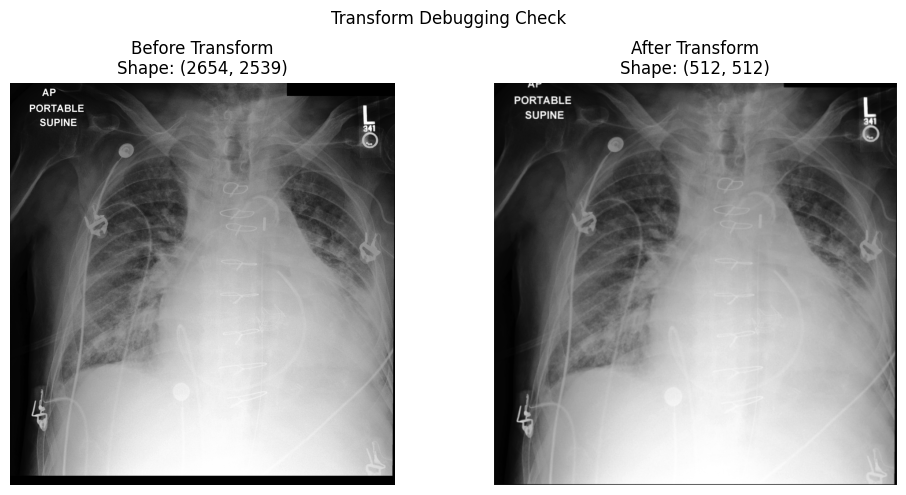

In [ ]:
import os
import torch
import skimage.io
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import torchvision.transforms as transforms
import torchxrayvision as xrv

seg_model = xrv.baseline_models.chestx_det.PSPNet().to(device)
seg_model.eval()

seg_transform = transforms.Compose([
    xrv.datasets.XRayCenterCrop(), # 기존처럼 CenterCrop으로 정사각형 비율 맞추기
    xrv.datasets.XRayResizer(512)  # 모델 규격에 맞게 512x512로 리사이징
])

anchor = 10 # 어디서부터 볼래?
num_images_to_process = 1 # 몇 개 볼래?

for i, img_path in enumerate(all_image_paths[anchor:anchor + num_images_to_process]):
    img = skimage.io.imread(img_path)
    img = xrv.datasets.normalize(img, 255) # 픽셀값 정규화

    if len(img.shape) > 2:
        img = img[:, :, 0] # 컬러(RGB)일 경우 첫 번째 채널(Gray)만 추출
    if len(img.shape) < 2:
        print("error, dimension lower than 2 for image")

    img = img[None, :, :] # [1, H, W]
    
    # 1. Transform 적용 전의 원본 비율/크기 확인용 변수 저장
    img_before_transform = img[0].copy() 

    # 2. Transform 적용
    img_transformed = seg_transform(img)

    # 3. Transform 전/후 비교 출력
    plt.figure(figsize=(10, 5))
    
    plt.subplot(1, 2, 1)
    plt.imshow(img_before_transform, cmap='gray')
    plt.title(f"Before Transform\nShape: {img_before_transform.shape}")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    # img_transformed는 (1, H, W) 형태이므로 [0]으로 2D 배열로 만듦
    plt.imshow(img_transformed[0], cmap='gray') 
    plt.title(f"After Transform\nShape: {img_transformed[0].shape}")
    plt.axis('off')
    
    plt.suptitle("Transform Debugging Check")
    plt.tight_layout()
    plt.show()

이미지: icu_cxr/mimic-cxr-jpg/2.1.0/files/p10/p10671739/s50762692/0f40ae81-c98bf6c8-517a41c6-9512149b-15771d94.jpg
--- Study ID: 50762692.0 ---
값이 1.0인 컬럼들:
['No Finding', 'Support Devices']
------------------------------


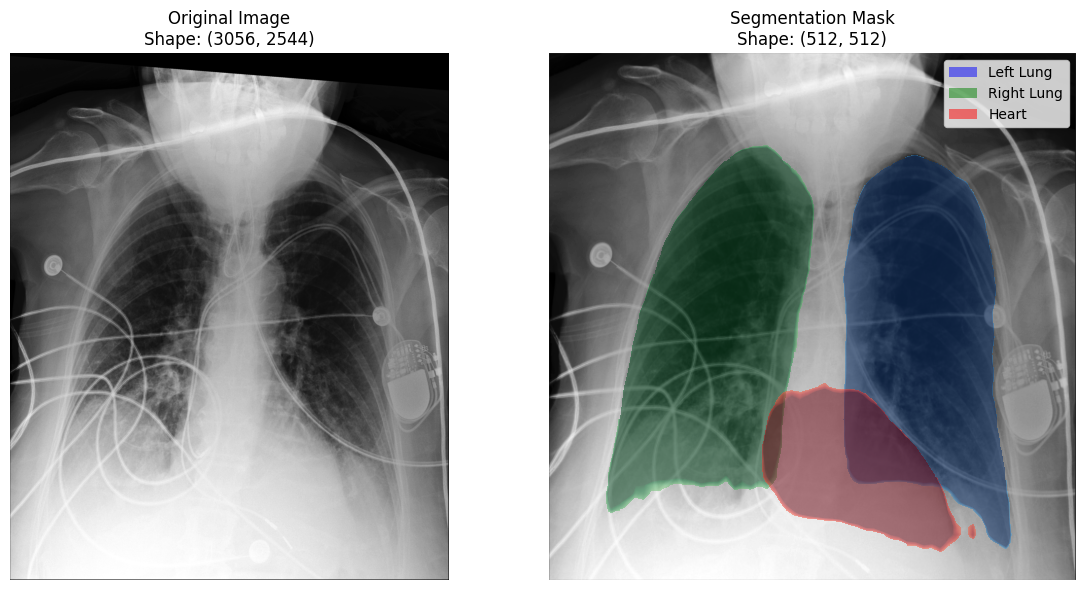

In [28]:
# --- 모델 로드 ---
seg_model = xrv.baseline_models.chestx_det.PSPNet().to(device)
seg_model.eval()

anchor = 3000 # 어디서부터 볼래?
num_images_to_process = 1 # 몇 개 볼래?

for i, img_path in enumerate(all_image_paths[anchor:anchor + num_images_to_process]):
    img = skimage.io.imread(img_path)
    img = xrv.datasets.normalize(img, 255) # 픽셀값 정규화

    if len(img.shape) > 2:
        img = img[:, :, 0] # 컬러(RGB)일 경우 첫 번째 채널(Gray)만 추출
    if len(img.shape) < 2:
        print("error, dimension lower than 2 for image")

    img = img[None, :, :] # [1, H, W]
    
    img_transformed = seg_transform(img)

    img_tensor = torch.from_numpy(img_transformed).unsqueeze(0).to(device) # [1, 1, H, W]

    # --- 추론 ---
    with torch.no_grad():
        outputs = seg_model(img_tensor) # [1, 14, 512, 512]
        masks = outputs[0].cpu().numpy()

    # 타겟 인덱스 추출 (4: Left Lung, 5: Right Lung, 8: Heart)
    left_lung_mask = masks[4]  
    right_lung_mask = masks[5] 
    heart_mask = masks[8]      

    print(f"이미지: {img_path}")
    study_id = img_path.split("/")[-2][1:]
    
    # 기존 라벨 확인 (생략 없이 그대로 유지)
    subject_df = label_csv[label_csv['study_id'] == int(study_id)]
    for index, row in subject_df.iterrows():
        positive_labels = row[row == 1.0]
        if not positive_labels.empty:
            print(f"--- Study ID: {row['study_id']} ---")
            print("값이 1.0인 컬럼들:")
            print(positive_labels.index.tolist())
        else:
            print(f"--- Study ID: {row['study_id']} ---")
            print("값이 1.0인 컬럼이 없습니다.")
        print("-" * 30)
                                
    # --- 시각화 ---
    plt.figure(figsize=(12, 6))
    
    # 1. 원본 이미지
    plt.subplot(1, 2, 1)
    orig_img = skimage.io.imread(img_path)
    plt.imshow(orig_img, cmap='gray')
    plt.title(f"Original Image\nShape: {orig_img.shape}")
    plt.axis('off')

    # 2. 세그멘테이션 마스크 오버레이 (512x512 기준)
    plt.subplot(1, 2, 2)
    # 배경 이미지도 512x512로 리사이즈된 텐서에서 가져옵니다
    bg_img_512 = img_tensor[0, 0].cpu().numpy() 
    plt.imshow(bg_img_512, cmap='gray')
    
    threshold = 0.5 
    # 마스크 오버레이 (투명도 alpha 적용)
    plt.imshow(np.ma.masked_where(left_lung_mask < threshold, left_lung_mask), cmap='Blues', alpha=0.5, vmin=0, vmax=1)
    plt.imshow(np.ma.masked_where(right_lung_mask < threshold, right_lung_mask), cmap='Greens', alpha=0.5, vmin=0, vmax=1)
    plt.imshow(np.ma.masked_where(heart_mask < threshold, heart_mask), cmap='Reds', alpha=0.5, vmin=0, vmax=1)
    
    legend_elements = [
        Patch(facecolor='blue', alpha=0.5, label='Left Lung'),
        Patch(facecolor='green', alpha=0.5, label='Right Lung'),
        Patch(facecolor='red', alpha=0.5, label='Heart')
    ]
    plt.legend(handles=legend_elements, loc='upper right')
    plt.title(f'Segmentation Mask\nShape: {bg_img_512.shape}')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

### Top 5 prediction

이미지: icu_cxr/mimic-cxr-jpg/2.1.0/files/p10/p10135376/s55191825/3e866bef-c0a9555c-9665a701-75c360dd-a961f9f1.jpg
--- Study ID: 55191825.0 ---
값이 1.0인 컬럼들:
['Edema', 'Pleural Effusion', 'Support Devices']
------------------------------
Effusion: 0.9651
Lung Opacity: 0.9330
Consolidation: 0.8674
Atelectasis: 0.8600
Enlarged Cardiomediastinum: 0.8379
---------------------------------------------------------------------------------------------------------------


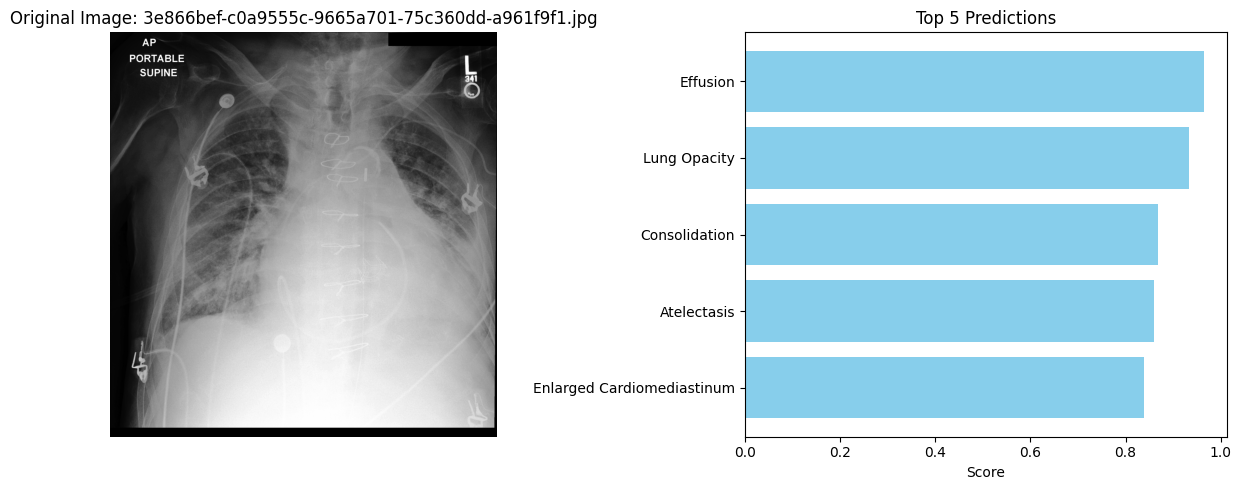

In [ ]:
model = xrv.models.DenseNet(weights="densenet121-res224-mimic_ch")
model = xrv.models.DenseNet(weights="all")

transform = torchvision.transforms.Compose([xrv.datasets.XRayCenterCrop(),xrv.datasets.XRayResizer(224)])

model.eval()

model.to(device)

anchor = 10 # 어디서부터 볼래?
num_images_to_process = 1 # 몇 개 볼래?

for i, img_path in enumerate(all_image_paths[anchor:anchor + num_images_to_process]):
    img = skimage.io.imread(img_path)
    img = xrv.datasets.normalize(img, 255) # 픽셀값 정규화

    if len(img.shape) > 2:
        img = img[:, :, 0] # 컬러(RGB)일 경우 첫 번째 채널(Gray)만 추출
    if len(img.shape) < 2:
        print("error, dimension lower than 2 for image")

    img = img[None, :, :]
    img = transform(img) 

    with torch.no_grad():
        img = torch.from_numpy(img).unsqueeze(0).to(device)
        outputs = model(img)
        # predictions = dict(zip(model.pathologies, outputs[0].cpu().numpy()))

        all_preds = zip(model.pathologies, outputs[0].cpu().numpy())
        predictions = {k: v for k, v in all_preds if k != ''}

    print(f"이미지: {img_path}")
    study_id = img_path.split("/")[-2][1:]
    subject_df = label_csv[label_csv['study_id'] == int(study_id)]
    for index, row in subject_df.iterrows():
        positive_labels = row[row == 1.0]

        if not positive_labels.empty:
            print(f"--- Study ID: {row['study_id']} ---")
            print("값이 1.0인 컬럼들:")
            print(positive_labels.index.tolist())
        else:
            print(f"--- Study ID: {row['study_id']} ---")
            print("값이 1.0인 컬럼이 없습니다.")
        print("-" * 30)
                                
    top5_predictions = sorted(predictions.items(), key=lambda item: item[1], reverse=True)[:5]
    for pathology, score in top5_predictions:
        print(f"{pathology}: {score:.4f}")
    print("-" * (len(img_path) + 5))

    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.imshow(skimage.io.imread(img_path), cmap='gray')
    plt.title(f"Original Image: {os.path.basename(img_path)}")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    top_pathologies = [item[0] for item in top5_predictions]
    top_scores = [item[1] for item in top5_predictions]
    plt.barh(top_pathologies, top_scores, color='skyblue')
    plt.xlabel('Score')
    plt.title('Top 5 Predictions')
    plt.gca().invert_yaxis() 
    plt.tight_layout()
    
    plt.show()
    
    if i >= num_images_to_process - 1:
        break

### XrayVision Model Classification Performance Check

In [ ]:
model = xrv.models.DenseNet(weights="densenet121-res224-mimic_ch")
model = xrv.models.DenseNet(weights="all")

model.to(device)

transform = torchvision.transforms.Compose([xrv.datasets.XRayCenterCrop(),xrv.datasets.XRayResizer(224)])

class XRayEvalDataset(Dataset):
    def __init__(self, image_paths, label_df, pathologies, transform=None):
        self.image_paths = image_paths
        self.label_df = label_df
        self.pathologies = pathologies
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        
        # --- 이미지 로드 및 전처리 ---
        img = skimage.io.imread(img_path)
        img = xrv.datasets.normalize(img, 255)
        if len(img.shape) > 2: 
            img = img[:, :, 0]
        img = img[None, :, :]
        
        if self.transform:
            img = self.transform(img)
            
        try:
            study_id = int(img_path.split("/")[-2][1:])
            subject_df = self.label_df[self.label_df['study_id'] == study_id]
            
            label_row = []
            if not subject_df.empty:
                for p in self.pathologies:
                    if p in subject_df.columns:
                        val = subject_df.iloc[0][p]
                        label_row.append(1 if val == 1.0 else 0)
                    else:
                        label_row.append(0)
            else:
                label_row = [0] * len(self.pathologies) # 라벨 데이터가 없는 경우
        except:
            label_row = [0] * len(self.pathologies)

        return torch.from_numpy(img), torch.tensor(label_row, dtype=torch.float32)

In [ ]:
eval_dataset = XRayEvalDataset(
    image_paths=all_image_paths, 
    label_df=label_csv, 
    pathologies=model.pathologies, 
    transform=transform
)

eval_loader = DataLoader(eval_dataset, batch_size=64, shuffle=False, num_workers=8)

In [ ]:
all_outputs = []
all_labels = []

target_paths = all_image_paths[:] # 전체 이미지를 대상으로 함

model.eval()
with torch.no_grad():
    for images, labels in tqdm(eval_loader, desc="Batch Processing"):
        images = images.to(device)

        outputs = model(images)

        all_outputs.append(outputs.cpu().numpy())
        all_labels.append(labels.numpy())

all_outputs = np.concatenate(all_outputs, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

print("\n" + "="*50)
print(f"전체 {len(target_paths)}장에 대한 성능 분석 결과")
print("="*50)

auc_scores = []
prc_scores = []

for i, pathology in enumerate(model.pathologies):
    if pathology == '': continue
    
    if len(np.unique(all_labels[:, i])) > 1:
        auc_val = roc_auc_score(all_labels[:, i], all_outputs[:, i])
        prc_val = average_precision_score(all_labels[:, i], all_outputs[:, i])

        auc_scores.append(auc_val)
        prc_scores.append(prc_val)

        print(f"{pathology:25s} |  {auc_val:.4f}  |  {prc_val:.4f}")
    else:
        print(f"{pathology:20s}: (데이터 부족으로 계산 불가)")

print("-" * 50)
print(f"{'Total Mean Score':25s} |  {np.mean(auc_scores):.4f}  |  {np.mean(prc_scores):.4f}")
print("="*50)

Batch Processing:   0%|          | 0/301 [00:00<?, ?it/s]


전체 19246장에 대한 성능 분석 결과
Atelectasis               |  0.6126  |  0.4023
Consolidation             |  0.6310  |  0.1302
Infiltration        : (데이터 부족으로 계산 불가)
Pneumothorax              |  0.6203  |  0.0932
Edema                     |  0.7099  |  0.3968
Emphysema           : (데이터 부족으로 계산 불가)
Fibrosis            : (데이터 부족으로 계산 불가)
Effusion            : (데이터 부족으로 계산 불가)
Pneumonia                 |  0.5473  |  0.0990
Pleural_Thickening  : (데이터 부족으로 계산 불가)
Cardiomegaly              |  0.6442  |  0.4382
Nodule              : (데이터 부족으로 계산 불가)
Mass                : (데이터 부족으로 계산 불가)
Hernia              : (데이터 부족으로 계산 불가)
Lung Lesion               |  0.6425  |  0.0331
Fracture                  |  0.5461  |  0.0202
Lung Opacity              |  0.6028  |  0.4085
Enlarged Cardiomediastinum |  0.5846  |  0.0724
--------------------------------------------------
Mean Score                |  0.6141  |  0.2094


In [ ]:
def plot_prc(y_true, y_scores, title="Precision-Recall Curve"):
    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    plt.step(recall, precision, where='post')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(title)
    plt.show()

# 4번째 라벨이 Edema
plot_prc(all_labels[:, 4], all_outputs[:, 4], title=model.pathologies[4])

NameError: name 'all_labels' is not defined

In [ ]:
path = "/home/DAHS1/gangmin/my_research/processed/cached_images_20260316/00a00bb82539b548602c42e997818a74.pt"

try:
    img = torch.load(path)
    print("Load success!")
    print("Type:", type(img))
    if hasattr(img, "shape"):
        print("Shape:", img.shape)
except Exception as e:
    print("❌ Load failed:", type(e).__name__, str(e))

Load success!
Type: <class 'torch.Tensor'>
Shape: torch.Size([1, 224, 224])


In [70]:
filtered_img_df = pd.read_feather('/home/DAHS1/gangmin/my_research/CXR/filtered_img_df_20260316.ftr')
filtered_img_df

,stay_id,hour_slot,image_path,hash_path
0,37510196,0,files/p10/p10001884/s57156853/9fd47edd-0708720...,C:\Users\gangmin\dahs\my research\final_dfs_20...
1,37510196,24,files/p10/p10001884/s50712381/7b25b3ed-e780a52...,C:\Users\gangmin\dahs\my research\final_dfs_20...
2,37510196,48,files/p10/p10001884/s56722923/c1ad3e27-62d05ef...,C:\Users\gangmin\dahs\my research\final_dfs_20...
3,37510196,78,files/p10/p10001884/s59305618/9b1a8a51-2b8e4a0...,C:\Users\gangmin\dahs\my research\final_dfs_20...
4,37510196,96,files/p10/p10001884/s50376803/469d0d94-3dad506...,C:\Users\gangmin\dahs\my research\final_dfs_20...
...,...,...,...,...
53223,35165301,81,files/p19/p19999287/s52519175/f7e95a22-cb95805...,C:\Users\gangmin\dahs\my research\final_dfs_20...
53224,35165301,99,files/p19/p19999287/s50000173/c8bbb9ff-ecb81ef...,C:\Users\gangmin\dahs\my research\final_dfs_20...
53225,32336619,8,files/p19/p19999442/s58708861/16b6c70f-6d36bd7...,C:\Users\gangmin\dahs\my research\final_dfs_20...
53226,36195440,6,files/p19/p19999987/s58971208/1a1fe7e3-cbac5d9...,C:\Users\gangmin\dahs\my research\final_dfs_20...


In [73]:
target_paths = filtered_img_df['image_path'].unique().tolist()

In [74]:
target_paths

['files/p10/p10001884/s57156853/9fd47edd-07087209-b901811e-3e9e5f50-f382f611.jpg',
 'files/p10/p10001884/s50712381/7b25b3ed-e780a527-319cb7b3-02d5d071-f1cddee9.jpg',
 'files/p10/p10001884/s56722923/c1ad3e27-62d05ef8-95018fe3-b8bcfe4b-bbba0e1f.jpg',
 'files/p10/p10001884/s59305618/9b1a8a51-2b8e4a04-1719059d-aa6bc888-7ace612b.jpg',
 'files/p10/p10001884/s50376803/469d0d94-3dad5068-efac76ef-a28cc502-68fe6275.jpg',
 'files/p10/p10002428/s57506266/e325a8d1-1d6b0dca-404efabc-204c6bbd-599788f0.jpg',
 'files/p10/p10002428/s57064083/217e6a56-b4a78227-a2acc34d-3b571d4a-27b9746a.jpg',
 'files/p10/p10002428/s52460896/54c2ed5c-f4fbc20d-3bf4c783-283c3878-e9eb320d.jpg',
 'files/p10/p10002428/s59414737/d999236f-95dcb8b7-a4d20a3f-be538f50-ce13a08e.jpg',
 'files/p10/p10002428/s56597576/d98d5096-a32483d3-669ed39b-bc81eafb-5e251563.jpg',
 'files/p10/p10002428/s56836542/471418ab-0bfd6700-6bb770d0-07f7f6a3-2ce2d9c2.jpg',
 'files/p10/p10002428/s50292543/7f51d06c-dad16fe6-ff21a632-edc5a3e6-ffa387bf.jpg',
 'fi

In [75]:
len(target_paths)

53228

In [ ]:
with open('my_subset_files.txt', 'w') as f:
    for path in target_paths:
        f.write(f"{path}\n")

print(f"총 {len(target_paths)}개의 경로가 저장되었습니다.")

총 53228개의 경로가 저장되었습니다.


In [ ]:
label_imputed_cxr = pd.read_feather('/home/DAHS1/gangmin/my_research/processed/label_imputed_cxr_20260126.ftr')
label_imputed_cxr

In [ ]:
label_imputed_cxr[(label_imputed_cxr['cxr_flag']==1) & (label_imputed_cxr['image_path'].isnull())]

,hadm_id,stay_id,hour_slot,slot_start,slot_end,cxr_flag,image_path,cxrtime,edema_pathophysiology,was_missing,label_source


In [ ]:
cxr_dataset = label_imputed_cxr.merge(filtered_img_df, how='left', on=['stay_id', 'hour_slot', 'image_path'])
cxr_dataset = cxr_dataset.drop(columns=['hadm_id', 'slot_start', 'slot_end', 'cxrtime'])
cxr_dataset = cxr_dataset.sort_values(['stay_id', 'hour_slot'])
cxr_5days_dataset = cxr_dataset[cxr_dataset['hour_slot'] <= 119].reset_index(drop=True)
cxr_5days_dataset = cxr_5days_dataset.drop(columns=['edema_pathophysiology', 'label_source', 'was_missing', 'image_path'])
cxr_5days_dataset['cxr_flag'] = cxr_5days_dataset['hash_path'].notna().astype(int) # New

In [ ]:
cxr_5days_dataset['hash_path'] = cxr_5days_dataset['hash_path'].apply(
    lambda x: PureWindowsPath(x).name if isinstance(x, str) else None
)

In [ ]:
print(cxr_5days_dataset['hash_path'][4])
print(cxr_5days_dataset['hash_path'][30])

997317ba341c810ae968d6b5fefcdccf.pt
809650ae1a042763fd81a266b7e27035.pt


In [ ]:
test = cxr_5days_dataset[cxr_5days_dataset['hash_path'].notnull()]

In [ ]:
broken_files = []
total = len(test)

for i in range(total):
    hash_path = test.iloc[i].hash_path
    full_path = os.path.join("/home/DAHS1/gangmin/my_research/processed/cached_images_20260316/", hash_path)

    try:
        _ = torch.load(full_path)
    except Exception as e:  
        broken_files.append(full_path)

print("====" * 20)
print(f"전체 파일 수: {total}")
print(f"손상된 파일 수: {len(broken_files)}")
print("====" * 20)

if len(broken_files) > 0:
    print("\n손상된 파일 목록:")
    for f in broken_files:
        print(f)

전체 파일 수: 37867
손상된 파일 수: 0


In [ ]:
cxr_5days_dataset

,stay_id,hour_slot,cxr_flag,hash_path
0,30000646,0,0,None
1,30000646,1,0,None
2,30000646,2,0,None
3,30000646,3,0,None
4,30000646,4,1,997317ba341c810ae968d6b5fefcdccf.pt
...,...,...,...,...
1039537,39998622,115,0,None
1039538,39998622,116,0,None
1039539,39998622,117,0,None
1039540,39998622,118,0,None


In [ ]:
cxr_5days_dataset.to_feather('/home/DAHS1/gangmin/my_research/src/test/total_cxr_df_5days_20260316.ftr')

In [ ]:
import torch

path = "/home/DAHS1/gangmin/my_research/CXR/cached_images_256_0317/997317ba341c810ae968d6b5fefcdccf.pt"
data = torch.load(path)

print("dtype:", data.dtype)
print("min:", data.min().item())
print("max:", data.max().item())
print("mean:", data.mean().item())
print("std:", data.std().item())

dtype: torch.bfloat16
min: 0.0
max: 1.0
mean: 0.5
std: 0.28515625
